# MiniQuant：AI 大模型从业者转量化模型岗

**路线**：不假设你炒过股。先建立市场、订单和收益的语言，再用真实日行情练完整研究闭环，随后进入 A 股盘口与逐笔事件，最后分别完成因子、模型、策略岗位作品。可执行代码有明确输入、时间线、基线与反证；插图是复习提纲。

这是一份研究和求职准备教材，不是投资建议，也不能替代交易所授权的 Level-2 数据、机构的合规交易环境或实际面试考核。

![量化研究闭环](figs/01_research_loop.png)

<!-- curriculum-audit-20260930 -->
**给 AI 算法工程师的阅读提示**：Python、回归、分类和神经网络原理只需快速复习；本书时间主要投入数据口径、事件顺序、标签、因子检验、组合、成交与复盘。先问‘这个数在当时能否知道、能否交易’，再问模型能否拟合。

## 0. 环境与导航
在项目根目录安装依赖并注册 Notebook 内核：

```bash
python -m pip install -r requirements.txt
python -m ipykernel install --user --name miniquant --display-name MiniQuant
```

在 Jupyter 中选择 `MiniQuant` 内核。冻结的真实数据位于 `data/real_equities.parquet`，默认运行不发起联网请求。视频配音是独立制作步骤，不影响 Notebook 运行。

建议用时：术语与数据 1 天，因子与模型 2 天，回测与审计 2 天，真实数据复做与报告 2–4 天。每章先预测代码结果，再运行、解释、改一个参数并记录变化。


In [1]:
import sys
from pathlib import Path
from matplotlib import font_manager
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)
SEED = 20260930
rng = np.random.default_rng(SEED)
plt.style.use("seaborn-v0_8-whitegrid")
font_file = Path("video/assets/NotoSansCJKsc-Regular.otf")
if font_file.exists():
    font_manager.fontManager.addfont(str(font_file))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font_file)).get_name()
    plt.rcParams["axes.unicode_minus"] = False

Python 3.10.14 | numpy 2.2.6 | pandas 2.3.3


### Python / NumPy / Pandas 速成：先看懂行和列
Python 的变量保存对象；列表是一串值，字典是键到值的映射。NumPy 数组适合批量数值计算；Pandas Series 是带索引的一列，DataFrame 是带行列标签的表。量化最常见的错误是把不同日期或不同股票的位置误当成同一行，所以先理解索引和对齐。下面的小练习不依赖行情。

In [2]:
values = np.array([100.0, 102.0, 99.0])
simple_return = values[1:] / values[:-1] - 1
mini = pd.DataFrame({"ticker": ["A", "A", "B"], "price": values})
print("NumPy 收益率:", simple_return)
display(mini.groupby("ticker")["price"].agg(["count", "mean"]))
assert np.isclose(simple_return[0], 0.02)

NumPy 收益率: [ 0.02       -0.02941176]


,count,mean
ticker,,
A,2,101.0
B,1,99.0


**自己做**：把初值改成 50，第一期收益率是否变化？为什么？尝试用 DataFrame 的 groupby、pivot、merge 分别回答“每支股票有多少天”、“日期×股票价格矩阵”、“价格与行业表怎样对齐”。遇到报错先读最后一行、确认输入类型，再让 AI 解释而不是直接改代码。

### 学习地图：三个量化研究实习岗位

| 岗位 | 核心问题 | 你要交付什么 | LLM 经验如何迁移 |
|---|---|---|---|
| 因子岗 | 某种盘口/逐笔行为能否稳定预测未来且可交易？ | 点时数据处理、因子定义、IC/分组、稳健性和版本化特征表 | 特征工程、数据流水线、离线评测 |
| 模型岗 | 如何在因子之上提高**扣成本后的**样本外表现？ | 明确标签、时序切分、基线、训练/调参、漂移监控 | 训练框架、实验管理、消融和泛化诊断 |
| 策略岗 | 信号如何变成真实可执行的仓位与订单？ | 股票池、组合权重、撮合/成本/容量、风控、复盘 | 端到端系统、线上监控、故障恢复 |

建议顺序：第 1 阶段市场与 Python → 第 2 阶段日频数据/因子/回测 → 第 3 阶段 A 股订单簿 → 第 4 阶段按岗位做作品。理解**决策时刻信息集**，比背模型名字更重要。

## 0.5 从零认识金融产品：先分清“买的是什么”

在写任何预测模型前，先问四件事：**我的钱换到了什么权利？回报由谁、用什么机制产生？亏损由谁承担？能否在需要时按可接受的价格退出？** “理财产品”只是日常称呼，不是统一的风险等级。产品、策略和交易市场是三条不同的轴。买入一只沪市股票、买入跟踪沪深 300 的 ETF、持有一份债券基金，都可能暴露于中国经济，但你拥有的权利、价格形成方式和交易规则不同。

| 名称 | 你实际持有什么 | 主要收益/损失来源 | 量化研究先检查什么 |
|---|---|---|---|
| 现金、银行存款 | 对银行的存款债权（具体保障按所在地制度） | 利息、通胀和银行/币种风险 | 计价货币、利率、通胀；不要把存款等同基金 |
| 债券 | 发行人的还本付息承诺 | 票息、利率变化、信用违约 | 到期日、久期、信用、成交深度 |
| 股票 | 一家公司的剩余权益 | 股价变动、可能的分红；可能亏掉投入本金 | 上市地、公司行动、股本、流动性 |
| 公募基金 | 按基金合同持有一篮子资产的份额 | 底层资产收益减费用 | 投向、净值、申购赎回规则、费率 |
| ETF | 可在交易所买卖的基金份额 | 底层资产、二级市场溢折价、费用 | 跟踪标的、净值与成交价、流动性 |
| 期货 | 在约定条件下交易标的的标准化合约 | 标的价格变动；保证金带来杠杆与追加保证金风险 | 合约乘数、到期/移仓、保证金、涨跌停 |
| 期权 | 买方支付权利金获得特定权利；卖方承担相应义务 | 标的价格、时间价值、波动率；卖方风险可能很大 | 行权价、到期日、权利金、希腊字母 |

**指数**是计算出来的统计尺子，不是一只股票；**指数基金**是试图跟踪这把尺子的基金，可能是 ETF，也可能是场外基金。基金的“分散”取决于真实持仓；单一行业或单只股票 ETF 并不会自动消除集中风险。普通场外基金通常按规则以基金净值申赎，ETF 的个人投资者通常在交易所按市场价格成交，后者可能偏离净值。不要把“固定收益”理解成“无风险”，也不要把期货的保证金误认为最大损失。

想象一家餐厅：股票像拥有一小份餐厅；债券像借钱给餐厅并约定偿还；基金像与许多人合资持有一篮子餐厅或债券；期货像约定将来按规则交换某种标的。这个比喻只帮助识别**权利结构**，不能替代产品合同。研究员拿到一个代码时，先确定它是股票、ETF、基金净值还是期货连续合约，再决定收益、成本、样本切分和能否成交。

资料：[SEC 投资产品入门](https://www.investor.gov/introduction-investing/investing-basics/investment-products)、[SEC 股票定义](https://www.investor.gov/introduction-investing/investing-basics/investment-products/stocks)、[SEC 基金与 ETF 差异](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/characteristics-mutual-funds-exchange-traded-funds)、[CFTC 期货入门](https://www.cftc.gov/LearnAndProtect/AdvisoriesAndArticles/FuturesMarketBasics/index.htm)。


![金融产品、包装与市场的三层地图](figs/05_product_market_map.png)

**读图方法：** “底层风险”说明赚赔从何而来；“产品包装”说明你持有哪种权利；“市场规则”决定能否下单、何时交收与怎样获得数据。先把三层分开，才不会把 ETF 当指数、把美股日线当 A 股盘口，或把 T+1 交收当成所有市场都禁止当日卖出。


### A 股、美股、港股：同叫“股票”，实验合同并不相同

“A 股”主要指在中国内地交易所上市、以人民币计价交易的股票；“美股”和“港股”是按上市交易市场说的，并非按公司国籍说的。同一家公司可能在不同市场有不同证券或存托凭证，不能用公司名称直接拼接价格。以下是**研究设计需要核对的差异**，不是可机械套用到所有板块、产品和账户的交易规则：

| 问题 | A 股（沪深股票为主） | 美股（美国上市股票为主） | 港股（香港上市股票为主） |
|---|---|---|---|
| 交易场所/货币 | 内地交易所、通常人民币 | 美国交易场所、通常美元 | 香港联交所、多数港元，另有多币种产品 |
| 当日买入再卖 | 普通 A 股通常不允许当日买入的股票当日卖出；ETF 等须逐产品核对 | 不能从 T+1 **交收**推断禁止当日买卖；账户类型等另有约束 | 交易与交收是两回事，须按证券及账户规则检查 |
| 证券/资金交收 | 按交易所、登记结算和产品规则核对 | 适用证券自 2024-05-28 起通常 T+1 | 港股交易所交易通常 T+2 |
| 价格限制 | 存在板块、风险警示、上市阶段等差异；不可统一写“涨跌停 10%” | 不把 A 股式单股日涨跌幅限制移植过来；需考虑停牌与市场熔断 | 不把 A 股涨跌停规则移植过来；需核对波动调节机制 |
| 做空/融资 | 融资融券有资格、标的和风控约束 | 有卖空、融券、账户等规则 | 指定证券和借券等规则约束 |
| 数据与公司行动 | 停牌、除权除息、ST、板块、交易日历 | 拆股、分红、退市、盘前盘后及跨时区 | 股息、配股、拆合股、南北向交易日差异 |

最容易混淆的是两种 “T+1”：**A 股买入后次日才能卖出**讲的是可否反向交易；**美股 T+1 交收**讲的是成交后证券与资金的最终划转。这两个维度必须分别建模。以 2026 年 9 月课程制作时可查的规则为准，正式研究应按交易所、板块、证券和日期查当时有效规则。例：某策略在美国股票上模拟“当天买、当天卖”，不能直接移植到普通 A 股；某日频美股模型的收益也不能充当 A 股十档盘口模型的证据。

为什么本书先用**真实美股日线**？公开、可冻结、可复现，适合学习数据→因子→标签→回测的因果纪律。第二篇转到 **A 股盘口/逐笔教学夹具**来练事件结构和规则；在拿到授权真实 Level-2 前，不报告 A 股高频收益。详见 [上交所交易机制](https://english.sse.com.cn/start/trading/mechanism/)、[港交所互联互通投资者手册](https://www.hkex.com.hk/-/media/HKEX-Market/Mutual-Market/Stock-Connect/Getting-Started/Information-Booklet-and-FAQ/Information-Book-for-Investors/Investor_Book_En_%28May%29.pdf)、[SEC 美股 T+1 交收说明](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/investor-bulletins/new-t1-settlement-cycle-what-investors-need-know-investor-bulletin)、[港交所证券交收](https://www.hkex.com.hk/services/settlement-and-depository/settlement?sc_lang=en)。


In [3]:
# 纯教学算例：把“价格收益、基金溢价、杠杆敞口”拆开；数字不是历史行情。
stock_buy, stock_sell = 100.0, 105.0
stock_return = stock_sell / stock_buy - 1
etf_nav, etf_market = 100.0, 101.0
etf_premium = etf_market / etf_nav - 1
futures_notional, initial_margin, underlying_move = 100_000.0, 10_000.0, -0.03
futures_pnl = futures_notional * underlying_move
margin_return = futures_pnl / initial_margin
print(f"股票价格收益（未计分红/费用）: {stock_return:.1%}")
print(f"ETF 成交价相对净值溢价: {etf_premium:.1%}")
print(f"期货标的变动 {underlying_move:.1%}，名义盈亏 {futures_pnl:.0f}，相对初始保证金 {margin_return:.1%}")
assert abs(stock_return - 0.05) < 1e-12 and abs(etf_premium - 0.01) < 1e-12
assert futures_pnl == -3000 and abs(margin_return + 0.3) < 1e-12


股票价格收益（未计分红/费用）: 5.0%
ETF 成交价相对净值溢价: 1.0%
期货标的变动 -3.0%，名义盈亏 -3000，相对初始保证金 -30.0%


**入门验收，先用口头回答再往下走：**
1. 某“沪深 300 指数 ETF”的“300”是什么、“ETF”是什么、“沪深”又是什么？三者分别落在哪一层？
2. 美股交易 T+1 交收，是否意味着今天买入今天不能卖出？普通 A 股为什么要单独检查？
3. 期货标的跌 3%、初始保证金为名义金额 10%，盈亏占保证金约多少？这是否就是最大亏损？
4. 一只股票分红或拆股后，原始收盘价与复权价分别适合回答什么问题？

**参考答案：** 指数是统计基准，ETF 是基金包装，沪深是成分/市场范围；交收周期不等于反向交易限制；本算例约亏保证金 30%，并非损失上限；原始价贴近历史报单价，复权价帮助估计持有期总回报，但不可把复权价当真实成交报价。


## 1. 必备术语：先把研究对象说清楚

| 术语 | 一句话解释 | 本项目里的位置 |
|---|---|---|
| 标的 / 股票池 universe | 能被研究或交易的一组股票 | 66 支现存股票；正式研究需逐日历史成分 |
| OHLCV | 开、高、低、收、成交量 | 原始行情表 |
| 复权价 adjusted price | 将分红、拆股等调整进可比较价格 | 计算历史收益与因子 |
| 收益率 | 两次可交易价格的相对变化 | 单资产和组合表现 |
| 因子 feature | 决策时已知的量化特征 | 动量、波动、均线偏离 |
| 标签 label | 事后观察到的预测目标 | 下一次开盘至再下一次开盘收益 |
| 横截面 | 同一时点比较多支股票 | 每日选股与 IC |
| 时间序列 | 同一股票跨日期比较 | 滚动因子与风险 |
| 基准 benchmark | 可投资的比较对象 | 同样时段等权持有 |
| 净值 NAV | 初始 1 元逐期复利后的价值 | 回测曲线 |
| bps | 基点；1 bp = 0.01% | 单边交易成本 |
| 换手 turnover | 权重变化绝对值之和 | 成本、容量与交易频率 |
| IC | 分数与未来收益的横截面相关 | 预测能力诊断 |
| 夏普 Sharpe | 超额均值 / 波动率，年化 | 风险收益，不保证未来表现 |
| 最大回撤 | 净值相对历史最高点的最大跌幅 | 尾部风险 |
| α / β | 相对基准的截距 / 市场敏感度 | 归因，不等于因果 |

**时间线**：日期 t 收盘后计算信号 → t+1 开盘以假设价格成交 → t+2 开盘结算一期收益。日频数据不能证明 t+1 开盘一定能按该价格成交；真实交易还需开盘竞价、停牌和流动性模型。

思考：为什么 t 日收盘价形成的信号不能在同一个收盘价无条件成交？

## 市场扫盲：买卖一股到底发生什么？

股票是公司所有权的一部分；交易所组织撮合，券商提交订单。**限价单**指定可接受价格，可能排队；**市价/最优价类申报**更重成交速度，可能承受滑点，具体可用类型随交易所、证券和时段变化。买一/卖一分别是最高买价/最低卖价；买卖价差 = 卖一−买一；中间价 = 两者均值。订单簿的一档显示该价位聚合数量，不等于你立即可以全部成交的真实容量。

先区分：一级市场发行与二级市场交易；现货、ETF、期货、期权的权利和风险；日收益、复利、分红拆股、总收益；基准、相对收益、绝对收益、风险预算。A 股实习尤其要知道沪深交易所、主板/创业板/科创板、集合竞价/连续竞价/收盘阶段、交易日与节假日、最小价位、涨跌幅约束、卖空与融资融券的资格和限制。规则会修订，写回测时把**交易日期、板块、证券状态**作为参数，按对应版本查交易所文件，不能写一个永久通用常数。官方入口：[上交所交易规则](https://www.sse.com.cn/lawandrules/sselawsrules2025/stocks/exchange/c/c_20260424_10816482.shtml)、[上交所 Level-2 产品说明](https://www.sseinfo.com/services/assortment/level2/)。

**练习**：给你买一 9.99 元×5,000 股、卖一 10.00 元×3,000 股，计算价差、中间价、价差 bps。为什么买入 10,000 股不能直接按 10.00 元成交？

In [4]:
bid, ask, ask_size = 9.99, 10.00, 3000
mid = (bid + ask) / 2
spread_bps = (ask - bid) / mid * 10_000
print(f"中间价 {mid:.3f} 元；全价差 {spread_bps:.2f} bps；卖一仅 {ask_size:,} 股")
assert ask > bid

中间价 9.995 元；全价差 10.01 bps；卖一仅 3,000 股


### 从金融基础到研究问题：Datawhale 知识地图

宏观、货币、投资学和统计是背景知识：利率、通胀、经济周期改变折现率和风险偏好；货币政策、收益率曲线和流动性会改变市场状态；均值、方差、协方差、假设检验、置信区间与多重检验决定你能否识别噪声。**宏观解释不能代替可检验信号**：给每个假设写公开时刻、影响机制、预测方向和反例。后续章节覆盖股票数据、选股、择时、组合优化、回测及机器学习。学习路径参考 [Datawhale whale-quant](https://github.com/datawhalechina/whale-quant)，本教材用独立叙述和代码重新组织。

### 宏观、货币与统计：面试够用的因果链

| 问题 | 基本概念 | 对量化模型的实际含义 |
|---|---|---|
| 利率为什么重要？ | 资金时间价值、期限结构、信用利差 | 折现率和融资/现金收益变动；宏观变量要按**公布时刻**对齐 |
| 通胀与货币政策如何影响市场？ | 货币供给、总需求/总供给、政策传导 | 可能改变波动与风格，但“相关”不是可交易因果 |
| 为什么不能只看均值？ | 分布、重尾、方差、协方差、抽样误差 | 同均值策略可能有完全不同的回撤和尾部风险 |
| 为什么样本内最优不可信？ | 假设检验、置信区间、多重比较 | 试了 100 个噪声因子也容易挑出“显著”的一个 |

给宏观因子建库时至少存 `observation_date`、`release_at`、`revision_at` 与 `available_at`；回测只用 `available_at ≤ decision_at` 的版本。利率可分无风险利率、政策利率与公司融资成本，不能混用。期望收益不确定，风险厌恶可用效用函数表达，但不能从一条历史净值反推出稳定的个人风险偏好。

### 第一关验收：先理解交易，再看模型

用自己的话解释：限价单为何可能排队；买一/卖一价差和冲击成本有什么区别；A 股现货、ETF、股指期货、商品期货在交易单位、保证金、卖空、结算与交易时段上为什么不能共用一套执行规则。能画出“委托→交易所撮合→回报→持仓”的路径，再进入数据章。**这些是市场制度问题，不是神经网络问题。**

## 2. 数据地基：真实行情与可审计的数据契约
我们使用 66 支股票、2010-01-04 至 2024-08-30 的真实历史日行情。它们来自公开数据的冻结子集，按今天仍在名单中的股票挑选，存在幸存者偏差。每个交易日每支股票一行。真实行情必须保存数据来源、抓取时间、复权方法、币种、时区和历史股票池快照。

In [5]:
from pathlib import Path
import hashlib, json
DATA_PATH = Path("data/real_equities.parquet")
MANIFEST_PATH = Path("data/manifest.json")
if not DATA_PATH.exists():
    raise FileNotFoundError("缺少冻结真实行情：data/real_equities.parquet；请先阅读 README 的数据准备说明")
manifest = json.loads(MANIFEST_PATH.read_text())
actual_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if actual_hash != manifest["sha256"]:
    raise ValueError("真实行情文件 SHA-256 与 manifest 不一致，停止研究")
bars = pd.read_parquet(DATA_PATH).sort_values(["date", "ticker"]).reset_index(drop=True)
dates = pd.DatetimeIndex(sorted(bars.date.unique()))
tickers = sorted(bars.ticker.unique())
n, k = len(dates), len(tickers)
print(f"真实行情：{k} 支股票、{n} 个交易日、{len(bars):,} 行")
print("时间范围：", dates.min().date(), "→", dates.max().date())
display(bars.head())

真实行情：66 支股票、3690 个交易日、243,540 行
时间范围： 2010-01-04 → 2024-08-30


,date,ticker,adj_close,close,high,low,open,volume,adj_open,adj_high,adj_low
0,2010-01-04,AAPL,6.572423,7.643214,7.660714,7.585000,7.622500,493729600.0,6.554611,6.587472,6.522365
1,2010-01-04,ADM,21.440180,31.469999,31.840000,31.330000,31.480000,3472500.0,21.446993,21.692258,21.344800
2,2010-01-04,ADSK,25.670000,25.670000,25.830000,25.610001,25.610001,2228600.0,25.610001,25.830000,25.610001
3,2010-01-04,AES,9.469493,13.670000,13.700000,13.380000,13.380000,4597600.0,9.268604,9.490274,9.268604
4,2010-01-04,AKAM,25.920000,25.920000,26.059999,25.530001,25.629999,3015600.0,25.629999,26.059999,25.530001


### 数据契约：错误必须响亮地失败
检查重复键、排序、缺失、正价格、OHLC 关系、成交量，以及每支股票是否有足够历史。这里 high/low 与复权 open/close 在同一尺度；导入真实数据时已把全部 OHLC 同步复权，不能把未复权高低价和复权收盘价混比。零成交量在本冻结样本中视为异常；真实市场里零成交、停牌需单独标记并定义处理规则。

In [6]:
def validate_bars(df: pd.DataFrame) -> None:
    required = {"date", "ticker", "adj_open", "adj_close", "adj_high", "adj_low", "volume"}
    assert required <= set(df.columns), f"缺少列: {required - set(df.columns)}"
    assert not df[list(required)].isna().any().any(), "存在缺失"
    assert not df.duplicated(["date", "ticker"]).any(), "日期-股票重复"
    assert (df[["adj_open", "adj_close", "adj_high", "adj_low"]] > 0).all().all(), "非正价格"
    assert (df["adj_high"] + 1e-10 >= df[["adj_open", "adj_close", "adj_low"]].max(axis=1)).all(), "最高价异常"
    assert (df["adj_low"] - 1e-10 <= df[["adj_open", "adj_close", "adj_high"]].min(axis=1)).all(), "最低价异常"
    assert (df["volume"] > 0).all(), "无成交量"
    assert (df.groupby("ticker").size() >= 100).all(), "历史长度不足"
    assert df.sort_values(["date", "ticker"]).index.equals(df.index), "请先按日期与股票排序"

validate_bars(bars)
dirty = bars.copy()
dirty.loc[0, "adj_close"] = -1
try:
    validate_bars(dirty)
except AssertionError as exc:
    print("脏数据被拦截：", exc)

脏数据被拦截： 非正价格


**实务提醒**：生产代码宜把 assert 改为显式 raise ValueError，因为 Python 的 -O 模式会关闭 assert。这里用 assert 让教学检查更直观。复权价格用于收益；若研究真实现金分红，应明确 total return 定义。当前成分股回看过去有幸存者偏差，完整研究需要逐日可得的历史股票池和退市证券。

### 真实数据的来源、快照与复权
冻结快照见 data/manifest.json。上游为 Kaggle 的 S&P 500 Stocks 数据，经 GitHub 镜像获取；仅选完整源文件中 66 支日期完整、价格与成交量非空的股票。原数据以 2024 年现存名单回溯历史，**不是逐日历史成分股**。调整后的开高低价用当日 adj_close/close 比例从原始价推算，便于教学，但不是逐笔可成交的复权价。下载脚本、来源和字段约定见 README。比较 raw close 和 adj_close 可以直观看到分红与拆股的影响；不要把两者混在同一个收益公式里。

In [7]:
display(pd.DataFrame({
    "raw_close": bars[bars.ticker == "MMM"].set_index("date").close,
    "adj_close": bars[bars.ticker == "MMM"].set_index("date").adj_close,
}).tail(5))
assert (bars.adj_close > 0).all()
assert not bars.duplicated(["date", "ticker"]).any()

,raw_close,adj_close
date,,
2024-08-26,131.850006,131.850006
2024-08-27,131.399994,131.399994
2024-08-28,131.610001,131.610001
2024-08-29,132.910004,132.910004
2024-08-30,134.690002,134.690002


### Parquet、增量更新与数据契约
Parquet 保留类型且适合列式读取。真实增量更新应先下载到临时文件、校验、按 (date,ticker) 合并，再做原子替换；同一天供应商可能修订历史，必须记录快照版本和差异。**永远不要在未核验字段与覆盖率时直接覆盖好数据。**本课程把真实数据固定为只读快照，便于每次运行得到同样输入。

## 3. 探索与统计：先看分布，再建模
用收益率而非价格直接比较不同股票。均值、标准差、相关系数是描述统计；相关不等于因果，也不会自动预测未来。

,mean,std,min,max
ticker,,,,
AAPL,0.0011,0.0177,-0.1286,0.1198
ADM,0.0004,0.0164,-0.2420,0.1027
ADSK,0.0009,0.0228,-0.1586,0.1620
AES,0.0004,0.0199,-0.1730,0.1496
AKAM,0.0006,0.0222,-0.1913,0.2404
...,...,...,...,...
WELL,0.0006,0.0183,-0.2440,0.2318
WMT,0.0006,0.0121,-0.1138,0.1171
WST,0.0009,0.0173,-0.1440,0.1454


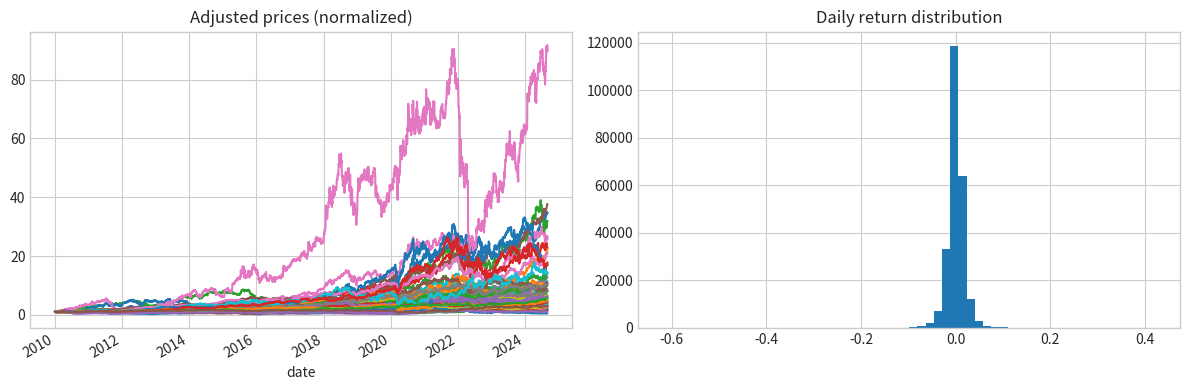

In [8]:
wide_close = bars.pivot(index="date", columns="ticker", values="adj_close")
wide_open = bars.pivot(index="date", columns="ticker", values="adj_open")
close_ret = wide_close.pct_change(fill_method=None)
summary = close_ret.agg(["mean", "std", "min", "max"]).T
display(summary.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(wide_close / wide_close.iloc[0]).plot(ax=axes[0], legend=False, title="Adjusted prices (normalized)")
close_ret.stack().hist(bins=60, ax=axes[1])
axes[1].set_title("Daily return distribution")
plt.tight_layout()
plt.show()

**动手题**：将日收益重采样为月收益，应该把日收益求和还是连乘？答案：复利应计算 (1+r) 连乘减 1。比较两种算法在波动大时的差异。

In [9]:
monthly = (1 + close_ret.fillna(0)).resample("ME").prod() - 1
display(monthly.head(3).round(3))

ticker,AAPL,ADM,ADSK,AES,AKAM,AMGN,AMZN,AON,AVY,AWK,...,SHW,STE,T,VLO,WBD,WELL,WMT,WST,WY,XOM
date,,,,,,,,,,,,,,,,,,,,,
2010-01-31,-0.103,-0.048,-0.073,-0.076,-0.047,0.013,-0.063,0.029,-0.118,-0.038,...,0.027,-0.078,-0.095,0.030,-0.043,-0.024,-0.015,-0.076,-0.098,-0.068
2010-02-28,0.065,-0.015,0.172,-0.074,0.065,-0.032,-0.056,0.052,-0.028,0.031,...,0.006,0.216,-0.022,-0.046,0.050,0.001,0.012,0.072,0.013,0.015
2010-03-31,0.148,-0.016,0.054,-0.059,0.195,0.057,0.147,0.043,0.160,-0.022,...,0.068,0.065,0.042,0.124,0.085,0.068,0.034,0.077,0.121,0.030


### 金融收益为何难学：重尾、异方差与时间依赖

同样叫“样本”，财经时间序列通常不满足独立同分布：收益可能有厚尾、波动聚集和制度切换；价格差分也不会自动变成正态。画正态曲线之前，先检查尾部频率、偏度、峰度和波动在不同时段的变化。我们在真实 AMZN 日收益上检验一个**描述性**问题，不把统计检验的 p 值当作交易信号。

In [10]:
from scipy.stats import jarque_bera, skew, kurtosis
amzn_r = close_ret["AMZN"].dropna()
z = (amzn_r - amzn_r.mean()) / amzn_r.std(ddof=1)
tail_rate = (z.abs() > 3).mean()
diagnostics = pd.Series({"偏度": skew(amzn_r), "超额峰度": kurtosis(amzn_r),
                         "|z|>3 实际比例": tail_rate,
                         "正态参考比例": 0.0027,
                         "JB 检验 p": jarque_bera(amzn_r).pvalue})
display(diagnostics.to_frame("真实 AMZN 日收益"))
assert 0 <= tail_rate <= 1

,真实 AMZN 日收益
偏度,0.265824
超额峰度,6.297749
|z|>3 实际比例,0.015451
正态参考比例,0.002700
JB 检验 p,0.000000


**区分四个概念**：价格的一阶差分 $P_t-P_{t-1}$ 有货币单位；简单收益 $P_t/P_{t-1}-1$ 无量纲；对数收益 $\log P_t-\log P_{t-1}$ 近似可加；按成交金额取样的 Dollar Bar 改变的是**采样轴**。差分与自定义轴不是同一个操作，任何“更接近正态”的说法都要在训练期和后续样本分别检验。

## 专题 A：经典均线策略与时间序列
短均线穿过长均线称金叉，向下穿过称死叉。策略只能在当日收盘确认交叉后，于下一交易时段执行。先在单只股票上做纯多头示意，再比较持有基准。均线窗口是超参数，不能在测试集反复挑最赚钱的一组。

金叉 36 死叉 37


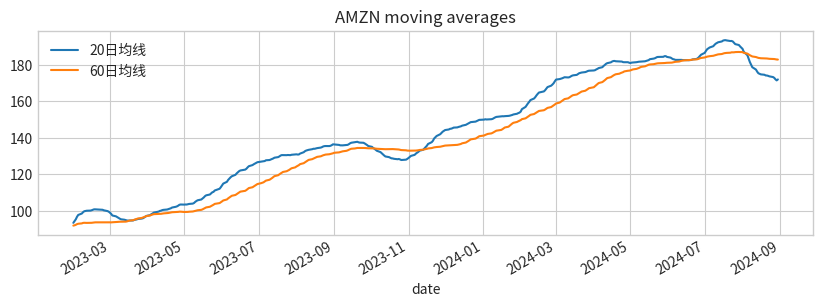

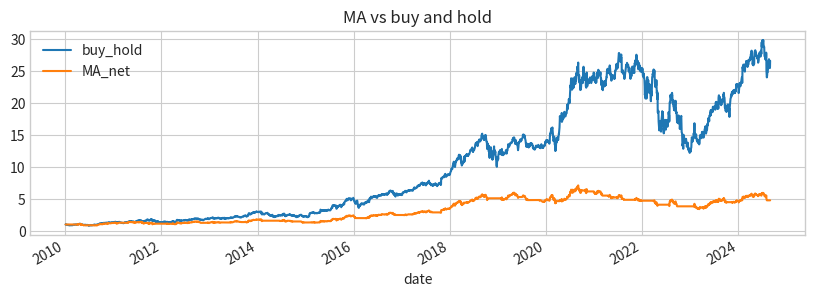

In [11]:
sample = wide_close["AMZN"]
fast, slow = sample.rolling(20).mean(), sample.rolling(60).mean()
cross_up = (fast > slow) & (fast.shift(1) <= slow.shift(1))
cross_down = (fast < slow) & (fast.shift(1) >= slow.shift(1))
ma_position = (fast > slow).shift(1).fillna(False).astype(int)
ma_ret = ma_position * sample.pct_change(fill_method=None).fillna(0)
ma_cost = ma_position.diff().abs().fillna(ma_position).mul(0.001)
ma_net = ma_ret - ma_cost
print("金叉", int(cross_up.sum()), "死叉", int(cross_down.sum()))
pd.DataFrame({"20日均线": fast, "60日均线": slow}).tail(400).plot(figsize=(10, 3), title="AMZN moving averages")
plt.show()
pd.DataFrame({"buy_hold": (1 + sample.pct_change(fill_method=None).fillna(0)).cumprod(),
              "MA_net": (1 + ma_net).cumprod()}).plot(figsize=(10, 3), title="MA vs buy and hold")
plt.show()

**核对**：日收益率的最后收盘成交假设与后面 t+1 开盘的模型回测口径不同，均线示意只帮助理解信号与延迟。真实订单需要开盘或下一可成交价，不能把这条曲线当成可交易绩效。重采样到月频时用 (1+r) 连乘减 1。原参考中关于买卖点、均线调参、年化、回撤、夏普与 α/β 的内容在本节和后面的绩效章节对应。

## 4. 从想法到因子
动量：过去 20 日复权涨跌；波动率：过去 20 日收益标准差；均线偏离：当前价相对过去 20 日均价。它们都是 t 收盘后才知道的值。因子并不因使用机器学习而过时，模型只能从提供的特征里学习。

滚动窗口开始的 NaN 是正常热身，不允许悄悄向前填充。对极端值可做截尾；横截面标准化必须逐日进行。用全样本未来均值来标准化会泄漏。

In [12]:
features = pd.DataFrame(index=wide_close.index)
def winsor_zscore(frame: pd.DataFrame) -> pd.DataFrame:
    lo = frame.quantile(0.05, axis=1)
    hi = frame.quantile(0.95, axis=1)
    clipped = frame.clip(lower=lo, upper=hi, axis=0)
    mu = clipped.mean(axis=1)
    sigma = clipped.std(axis=1, ddof=0).replace(0, np.nan)
    return clipped.sub(mu, axis=0).div(sigma, axis=0)

momentum = wide_close / wide_close.shift(20) - 1
volatility = close_ret.rolling(20, min_periods=20).std()
ma_gap = wide_close / wide_close.rolling(20, min_periods=20).mean() - 1
factor_panels = {
    "momentum": winsor_zscore(momentum),
    "volatility": winsor_zscore(volatility),
    "ma_gap": winsor_zscore(ma_gap),
}
factor_table = pd.concat(
    {name: panel.stack(future_stack=True) for name, panel in factor_panels.items()},
    axis=1
).rename_axis(index=["date", "ticker"])
display(factor_table.dropna().head())
assert np.isfinite(factor_table.dropna().to_numpy()).all()

momentum  volatility    ma_gap
date       ticker                                
2010-02-02 AAPL   -1.068494    0.711311 -1.243868
           ADM     0.248039   -0.427344  0.996952
           ADSK   -0.807732   -0.402233 -1.307279
           AES    -0.415677    0.199037 -0.545887
           AKAM    0.427843    0.524228  0.230209

### 因果截断测试
如果只用截至某日的数据重新算因子，这一天的结果应不变。这个测试能抓到常见的 shift(-1) 或未来滚动窗口；它不能证明所有特征都没有泄漏，仍需逐项检查发布时间、修订历史和数据供应商字段。

In [13]:
cut = 150
partial = wide_close.iloc[:cut]
partial_momentum = winsor_zscore(partial / partial.shift(20) - 1)
pd.testing.assert_series_equal(
    factor_panels["momentum"].iloc[cut-1],
    partial_momentum.iloc[-1],
    check_names=False,
)
print("动量因子通过截断测试；决策日：", dates[cut-1].date())

动量因子通过截断测试；决策日： 2010-08-06


## 专题 B：去极值、标准化与中性化
百分位截尾、MAD（中位数绝对偏差）和 3σ 都是在同一天的横截面上处理极值。MAD 对极端值更稳健；3σ 依赖均值与标准差，重尾分布下可能失灵。z-score 改变量纲；行业或市值中性化是将这些暴露回归掉，只能使用当时可得的行业/市值表。当前冻结行情没有 point-in-time 市值和行业，因此只演示与可得的成交额代理变量正交化，**不能称作真正的市值/行业中性化**。

In [14]:
def clip_cross_section(values: pd.Series, method: str) -> pd.Series:
    x = values.astype(float)
    if method == "percentile":
        return x.clip(x.quantile(.05), x.quantile(.95))
    if method == "mad":
        med = x.median(); mad = (x - med).abs().median()
        return x.clip(med - 3 * 1.4826 * mad, med + 3 * 1.4826 * mad)
    if method == "sigma":
        return x.clip(x.mean() - 3 * x.std(), x.mean() + 3 * x.std())
    raise ValueError(method)

one_day = factor_table.xs(dates[100], level="date").momentum.dropna()
demo = pd.DataFrame({name: clip_cross_section(one_day, name) for name in ["percentile", "mad", "sigma"]})
display(demo.describe().round(2))
def residualize(y: pd.Series, exposure: pd.Series) -> pd.Series:
    design = np.column_stack([np.ones(len(y)), exposure.to_numpy()])
    coef, *_ = np.linalg.lstsq(design, y.to_numpy(), rcond=None)
    return pd.Series(y.to_numpy() - design @ coef, index=y.index)

raw_dollar_volume = bars.assign(dollar_volume=bars.close * bars.volume)
# 实际示范选取同一日期，避免日期错配。
sample_date = dates[100]
exposure = raw_dollar_volume[raw_dollar_volume.date == sample_date].set_index("ticker").dollar_volume
neutralized = residualize(one_day, np.log(exposure.reindex(one_day.index)))
print("与成交额代理的相关：前", round(one_day.corr(np.log(exposure)), 3),
      "后", round(neutralized.corr(np.log(exposure)), 3))

,percentile,mad,sigma
count,66.00,66.00,66.00
mean,-0.00,0.00,0.00
std,1.00,1.01,1.01
min,-1.73,-1.75,-1.75
25%,-0.78,-0.78,-0.78
50%,-0.01,-0.01,-0.01
75%,0.77,0.77,0.77
max,1.94,1.96,1.96


与成交额代理的相关：前 -0.003 后 -0.0


**练习**：构造一个极端离群值，比较三种截尾；再解释为什么全样本统一 z-score 会泄漏时间信息。真实多因子研究还需处理行业虚拟变量、报告值公布日、缺失值和中性化后的解释性。

### 从选股到择时：经典模型在什么位置？

均值—方差理论用预期收益和协方差找有效前沿；CAPM 用市场 beta 解释收益，APT/多因子模型使用多个系统性暴露。它们是**风险与定价框架**，不是直接可复制的盈利公式。技术分析常见均线、MACD、动量、反转；异常效应、资金流和情绪可提出择时假设。Hurst 指数描述持久性，SVM 和状态转换模型可识别市场状态；状态标签必须仅用当时数据估计。浪形、图形和新闻情绪若缺乏可重复定义与样本外检验，应保持为探索性观察。

当你的目标是 A 股盘口模型，日频基线仍有价值：它检验高频复杂度是否真的带来增量。

### MACD 与趋势：算得出，还要说出滞后

MACD 的 DIF 是快 EMA 减慢 EMA；DEA 是 DIF 的 EMA；柱线是 DIF−DEA（有的平台乘 2，须注明口径）。均线和 MACD 都用历史价格，趋势变化确认往往滞后，不能从事后图中的最低点回填买入。以下只展示指标计算，不在测试集搜索最佳参数。

,DIF,DEA,histogram
date,,,
2024-08-26,-1.398,-2.678,1.280
2024-08-27,-1.496,-2.442,0.946
2024-08-28,-1.741,-2.302,0.561
2024-08-29,-1.808,-2.203,0.395
2024-08-30,-1.330,-2.028,0.698


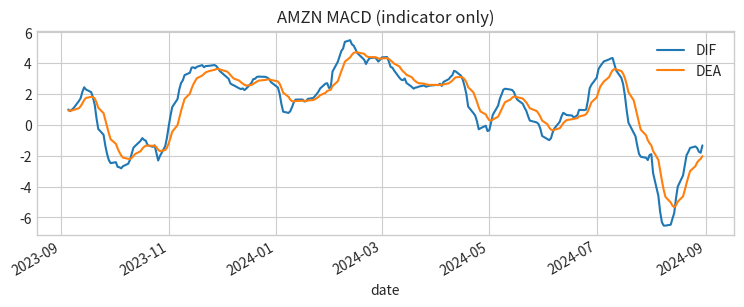

In [15]:
amzn_price = wide_close["AMZN"]
ema_fast = amzn_price.ewm(span=12, adjust=False).mean()
ema_slow = amzn_price.ewm(span=26, adjust=False).mean()
dif = ema_fast - ema_slow
dea = dif.ewm(span=9, adjust=False).mean()
macd = pd.DataFrame({"DIF": dif, "DEA": dea, "histogram": dif-dea})
display(macd.tail(5).round(3))
macd.iloc[-250:][["DIF","DEA"]].plot(figsize=(9,3), title="AMZN MACD (indicator only)")
plt.show()

### 第二关验收：因子不是越多越好

金融假设型特征先说明机制：例如盘口失衡反映哪一侧短期供需、何时可能失效；数学变换型特征则如滚动均值、差分、PCA，能压缩或变换输入，却不自动产生可交易原因。非时间轴上的“过去 5 根 Bar”覆盖的日历时间不固定，因此滚动窗口必须同时报告 Bar 数与实际历时。信息熵 $H=-\sum p_i\log_2p_i$ 可描述方向分布的不确定性，但估计样本少时偏差大；不能把高熵或低熵直接当成 alpha。

In [16]:
# 真实日行情上的一个非价格因子：过去 20 日平均成交额相对自身历史的变化。
dollar_turnover = bars.assign(dollar_turnover=bars.close * bars.volume).pivot(
    index="date", columns="ticker", values="dollar_turnover")
liquidity_ratio = dollar_turnover.rolling(20, min_periods=20).mean() /                   dollar_turnover.rolling(120, min_periods=120).mean()
print("流动性变化因子在 2024-08-30 可得的股票数:", int(liquidity_ratio.iloc[-1].notna().sum()))
assert liquidity_ratio.iloc[:119].isna().all().all()
# 这仍非真实盘口因子，也未处理 A 股停牌、涨跌停和点时股票池。

流动性变化因子在 2024-08-30 可得的股票数: 66


## 5. 标签、可得性与切分
在 t 收盘后产生分数，标签定义为 t+1 开盘买入、t+2 开盘卖出的复权收益。这个标签用于训练和事后评估，**绝不能进入当时的特征**。末尾两日没有完整标签。训练集按日期切；训练末端至少留出 2 日隔离，因为临近切分点的标签可能用到测试期价格。这里固定一次训练，只在测试期预测；若要定期重训，必须逐个训练日做 walk-forward，且每次重新遵守标签可得性。

In [17]:
future_open_ret = wide_open.shift(-2) / wide_open.shift(-1) - 1
label = future_open_ret.stack(future_stack=True).rename("target")
panel = factor_table.join(label).reset_index()
panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna().sort_values(["date", "ticker"]).reset_index(drop=True)
feature_names = ["momentum", "volatility", "ma_gap"]
assert panel[feature_names + ["target"]].notna().all().all()
train_end_i = int(len(dates) * 0.70)
test_start_i = train_end_i + 5
train = panel[panel["date"] <= dates[train_end_i]].copy()
test = panel[panel["date"] >= dates[test_start_i]].copy()
assert train["date"].max() < test["date"].min()
assert dates[train_end_i + 2] < dates[test_start_i + 1], "标签与执行区间隔离不足"
print("训练决策日期：", train.date.min().date(), "至", train.date.max().date())
print("测试决策日期：", test.date.min().date(), "至", test.date.max().date())
print("样本数：", len(train), len(test))

训练决策日期： 2010-02-02 至 2020-04-08
测试决策日期： 2020-04-16 至 2024-08-28
样本数： 169224 72600


训练 / 验证 / 测试应有不同职责：训练拟合参数，验证选模型与超参数，测试只用于最终报告。此演示事先固定 Ridge 的 alpha=10；没有在测试上搜索。真实项目要在训练段内再做时间滚动验证并记录所有试验。随机切分会把未来市场状态带进训练，不能用作时序研究的最终证据。

### 标签工程：答案的形状决定模型回答什么

同一价格路径可以产生不同标签：固定持有期收益适合回归，超过训练期阈值的上/平/下适合分类；止盈/止损/超时三道屏障对应路径依赖事件标签；趋势扫描则寻找未来窗口的趋势方向。**标签允许事后看未来，但特征和筛选阈值不能。** 标签密度是每单位时间触发多少事件，过密会造成高度重叠；过疏又使有效样本太少。分类平衡不应靠反复查看测试期来“调”阈值。

In [18]:
# 用既有真实 AMZN 收盘价演示固定期限三分类；这里只是标签设计比较。
amzn = wide_close["AMZN"]
future5 = amzn.shift(-5) / amzn - 1
train_cut = train.date.max()
threshold = future5.loc[:dates[train_end_i-5]].abs().quantile(.60)  # 标签终点也留在训练期
three_way = pd.Series(np.select([future5 > threshold, future5 < -threshold],
                                [1, -1], default=0), index=amzn.index)
three_way[future5.isna()] = np.nan
print("训练期阈值:", round(float(threshold), 4))
display(three_way.loc[train.date.min():train_cut].value_counts(normalize=True).sort_index()
        .rename("训练期标签密度").to_frame())
assert three_way.iloc[-5:].isna().all()

训练期阈值: 0.03


,训练期标签密度
-1.0,0.154446
0.0,0.598674
1.0,0.246880


**路径型标签的边界**：如果只存日收盘，就不知道日内先碰止盈还是先碰止损；用日线 high/low 也可能同时碰到两道屏障，需保守处理或更细粒度数据。未来 5 日标签在相邻日期共享大部分价格路径；随机分行交叉验证会让相近答案同时落入训练与验证。

In [19]:
# 用显式的标签区间演示 purge：训练事件的结束时间不得碰到验证区间。
toy_events = pd.DataFrame({"start": pd.to_datetime(["2024-01-02","2024-01-04","2024-01-08"]),
                           "end":   pd.to_datetime(["2024-01-05","2024-01-10","2024-01-09"])})
valid_start, valid_end = pd.Timestamp("2024-01-08"), pd.Timestamp("2024-01-12")
overlap = (toy_events.start <= valid_end) & (toy_events.end >= valid_start)
display(toy_events.assign(overlaps_validation=overlap))
assert overlap.tolist() == [False, True, True]
# 实际 walk-forward 还须逐折重拟合预处理器，并为延迟与相关性留 embargo。

,start,end,overlaps_validation
0,2024-01-02,2024-01-05,False
1,2024-01-04,2024-01-10,True
2,2024-01-08,2024-01-09,True


## 6. 两个基线与一个可解释模型
基线 A：直接用动量排序。基线 B：每天等权持有整个股票池。模型：Ridge 线性回归，以训练集拟合标准化器和权重。标准化器放在 Pipeline 中，避免用测试期统计量。预测值是排序分数，不要把它当成可靠的价格或收益承诺。

In [20]:
model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
model.fit(train[feature_names], train["target"])
test["score"] = model.predict(test[feature_names])
test["momentum_score"] = test["momentum"]
coef = pd.Series(model.named_steps["ridge"].coef_, index=feature_names)
display(coef.rename("Ridge 权重").to_frame())
display(test[["date", "ticker", "score", "target"]].head())

,Ridge 权重
momentum,0.000001
volatility,0.000083
ma_gap,0.000009


,date,ticker,score,target
169488,2020-04-16,AAPL,0.000564,-0.023675
169489,2020-04-16,ADM,0.000562,-0.003542
169490,2020-04-16,ADSK,0.000666,0.011983
169491,2020-04-16,AES,0.000652,0.022240
169492,2020-04-16,AKAM,0.000562,-0.000094


## 7. 预测诊断：IC 和分层
每天在同一横截面上算 Spearman 排序相关，再汇总均值；某一天所有值相同则 IC 不可定义，应记为缺失而非 0。分层检验按预测分五组，比较各组事后收益。重叠标签、多次调参和市场共振会使简单 t 统计显得过度自信。

In [21]:
def daily_ic(df: pd.DataFrame, score_col: str) -> pd.Series:
    def one_day(g):
        if g[score_col].nunique() < 2 or g["target"].nunique() < 2:
            return np.nan
        return spearmanr(g[score_col], g["target"]).statistic
    return df.groupby("date", sort=True).apply(one_day, include_groups=False).rename("IC")

ic_model = daily_ic(test, "score")
ic_mom = daily_ic(test, "momentum_score")
print(pd.DataFrame({"Ridge": ic_model, "动量基线": ic_mom}).agg(["mean", "std", "count"]).round(4))
rank_pct = test.groupby("date")["score"].rank(pct=True, method="first")
test["quintile"] = np.minimum(np.ceil(rank_pct * 5).astype(int), 5)
display(test.groupby("quintile")["target"].mean().rename("下一期平均收益").to_frame())

           Ridge       动量基线
mean      0.0067    -0.0002
std       0.2734     0.2414
count  1100.0000  1100.0000


,下一期平均收益
quintile,
1,0.000574
2,0.000635
3,0.000692
4,0.000932
5,0.001105


**自查**：IC 为负时可能意味着方向错、市场状态变化，也可能只是噪声；先看样本期、分布和成本，不能直接把分数乘 -1 再把同一测试集当作独立验证。

### 降维不是免费压缩：训练与实时推理必须同构

相关因子过多会使估计不稳。过滤法删除常数、高缺失和高相关列；PCA 把原特征旋转成少数方向；正则化在不显式降维时限制系数。PCA 最大化输入方差，不保证最大化预测能力，也会损失解释性。选择维度、标准化器和 PCA 只能拟合训练期；上线时每个原始特征仍要按相同顺序、单位和时刻到达，缺一项不能随意补 0。

In [22]:
from sklearn.decomposition import PCA
compressed = make_pipeline(StandardScaler(), PCA(n_components=2), Ridge(alpha=10.0))
compressed.fit(train[feature_names], train.target)
test["pca_score"] = compressed.predict(test[feature_names])
print("PCA 训练期累计解释方差:", round(float(compressed.named_steps["pca"].explained_variance_ratio_.sum()), 3))
print("原 Ridge 测试 IC:", round(float(daily_ic(test, "score").mean()), 4),
      "PCA+Ridge 测试 IC:", round(float(daily_ic(test, "pca_score").mean()), 4))
assert test.pca_score.notna().all()

PCA 训练期累计解释方差: 0.947


原 Ridge 测试 IC: 0.0067 PCA+Ridge 测试 IC: 0.0067


**验收**：能解释“输入维度减少”与“实时原始字段减少”为什么不是一回事；能给出模型包所需的列名顺序、训练期统计量、版本号、缺失回退和延迟预算。测试 IC 没改善时，不为 PCA 额外复杂度找借口。

## 专题 C：因子分析、分组收益与打分法
IC 是预测排名与事后收益排名的相关；因子收益可以用最高组减最低组的未来收益估计。分组单调性比只盯平均 IC 更能暴露不稳定性。打分法先逐日标准化，再按事先固定权重加权；它是机器学习的有意义基线，不需要大模型。

In [23]:
test["rule_score"] = .5 * test.momentum - .3 * test.volatility + .2 * test.ma_gap
for label_name, col in [("动量", "momentum"), ("规则打分", "rule_score"), ("Ridge", "score")]:
    values = daily_ic(test, col)
    print(label_name, "平均 IC", round(values.mean(), 4), "IC 正值占比", round((values > 0).mean(), 3))
test["rule_bin"] = np.ceil(test.groupby("date").rule_score.rank(pct=True, method="first") * 5).clip(1, 5).astype(int)
display(test.groupby("rule_bin").target.agg(["mean", "count"]).round(5))

动量 平均 IC -0.0002 IC 正值占比 0.495


规则打分 平均 IC -0.0053 IC 正值占比 0.484


Ridge 平均 IC 0.0067 IC 正值占比 0.517


,mean,count
rule_bin,,
1,0.00090,14300
2,0.00101,14300
3,0.00076,14300
4,0.00063,14300
5,0.00067,15400


Alphalens 的常见图包括 IC 时间序列、分位数组合未来收益、换手和因子衰减。本节用透明的 Pandas 实现核心计算，避免工具包默认对齐方式掩盖时间错误。分组结果有重叠持有期时需另处理统计依赖。

### 机器学习分类：给 Ridge 一个非线性对手

“上涨/下跌”分类以未来收益正负为标签。准确率常受类别比例影响，应该同时看平衡准确率、概率校准、排名 IC 和扣成本策略收益。这里用训练期子样本快速比较 Logistic 与直方图梯度提升树；真实项目还要做时间滚动验证、股票/时段分层和置信区间。LightGBM 是高效梯度提升树的常见实现，但版本和数据量不应替代正确时间线。

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
fit_rows = train.iloc[::3].copy()  # 仅为课程执行速度抽样；保持时间段不变
y_fit = (fit_rows.target > 0).astype(int)
y_test = (test.target > 0).astype(int)
classifiers = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, random_state=SEED)),
    "hist_gbdt": HistGradientBoostingClassifier(max_iter=80, max_leaf_nodes=15, random_state=SEED),
}
classification_rows = []
for name, clf in classifiers.items():
    clf.fit(fit_rows[feature_names], y_fit)
    prob = clf.predict_proba(test[feature_names])[:,1]
    classification_rows.append({"model": name,
        "balanced_accuracy": balanced_accuracy_score(y_test, prob >= .5),
        "AUC": roc_auc_score(y_test, prob),
        "daily_IC": daily_ic(test.assign(classifier_score=prob), "classifier_score").mean() if "daily_ic" in globals() else np.nan})
display(pd.DataFrame(classification_rows).round(4))
print("类别基准(正收益占比):", round(y_test.mean(),3))

,model,balanced_accuracy,AUC,daily_IC
0,logistic,0.5000,0.5042,-0.0079
1,hist_gbdt,0.5004,0.5036,-0.0047


类别基准(正收益占比): 0.524


小波分解用于多尺度信号分析，但双向去噪滤波可能在历史 t 点用到未来价格；若用于交易，必须用**因果/单边窗口**，在每个历史时刻只处理过去。SVM 可作为中小样本非线性基线；LSTM 的门控处理序列依赖，CNN/池化提取局部模式，Dropout 抑制过拟合。序列模型需要按交易日构造窗口、在股票边界截断、仅在训练期拟合归一化，并与简单基线比较。新闻、公告、研报和舆情是非结构化输入：正文、发布时间、抓取时间和修订记录都要存，LLM 摘要不能把未来公告写回过去。

### 多模型/多轴组合：先看增量，再谈“集成”

因子分数、线性模型、树模型可按预先固定的权重合成；不同采样轴的模型必须先对齐到**同一个决策时刻**，且不能把尚未结束的 Bar 当已知。看单模型与组合的 IC、相关性、换手、成本后收益和市场状态；若两个模型错误高度同向，平均并不能分散风险。这里做固定 50/50 排名融合，**不在测试期优化权重**。

In [25]:
rank_ridge = test.groupby("date").score.rank(pct=True)
rank_rule = test.groupby("date").rule_score.rank(pct=True)
test["fixed_blend"] = .5 * rank_ridge + .5 * rank_rule
ic_check = pd.Series({name: daily_ic(test, col).mean()
                      for name, col in [("Ridge", "score"), ("规则", "rule_score"),
                                        ("固定融合", "fixed_blend")]})
display(ic_check.rename("测试期平均 IC").to_frame().round(4))
assert test.fixed_blend.between(0, 1).all()

,测试期平均 IC
Ridge,0.0067
规则,-0.0053
固定融合,0.0020


## 8. 从信号到组合
每个决策日选择最高 25% 做多，最低 25% 做空，各侧总权重 0.5，净敞口 0、总敞口 1。卖空需要借券、保证金并可能付融券费，真实研究不能默认可做空。备选的纯多头策略更适合不能融券的账户。

权重从 t 日分数产生，在 t+1 开盘交易并持有到 t+2 开盘。当前简化研究不含停牌、涨跌停、开盘冲击和市场容量，后续必须补。

In [26]:
def make_weights(df: pd.DataFrame, score_col: str, side_frac: float = 0.25) -> pd.DataFrame:
    rows = []
    for date, g in df.groupby("date", sort=True):
        g = g.sort_values([score_col, "ticker"]).copy()
        n_side = max(1, int(len(g) * side_frac))
        assert 2 * n_side <= len(g), "股票池太小"
        g["weight"] = 0.0
        g.iloc[:n_side, g.columns.get_loc("weight")] = -0.5 / n_side
        g.iloc[-n_side:, g.columns.get_loc("weight")] = 0.5 / n_side
        rows.append(g[["date", "ticker", "weight", "target"]])
    return pd.concat(rows, ignore_index=True)

weights = make_weights(test, "score")
check = weights.groupby("date")["weight"].agg(net="sum", gross=lambda x: x.abs().sum())
assert np.allclose(check["net"], 0)
assert np.allclose(check["gross"], 1)
display(weights.head(12))

,date,ticker,weight,target
0,2020-04-16,CLX,-0.03125,0.007830
1,2020-04-16,IEX,-0.03125,0.001996
2,2020-04-16,WMT,-0.03125,0.006921
3,2020-04-16,CPB,-0.03125,-0.015378
4,2020-04-16,PGR,-0.03125,0.008022
5,2020-04-16,GOOGL,-0.03125,-0.009214
6,2020-04-16,AMZN,-0.03125,0.007427
7,2020-04-16,MRK,-0.03125,-0.013461
8,2020-04-16,NFLX,-0.03125,0.009675
9,2020-04-16,K,-0.03125,0.011184


### 从目标权重到成交：一笔订单的诚实故事

模型建议买 10,000 股时，卖一只有 3,000 股，不能把 10,000 股全按卖一成交。下面依次消耗可见卖档，计算实际成交量、均价与剩余未成交；这是**确定性教学撮合**，不包含其他参与者抢单、撤单、隐藏量、队列优先或延迟。

In [27]:
ask_levels = [(10.00, 3000), (10.01, 4000), (10.03, 1000)]
remaining, spent = 10_000, 0.0
for price, available in ask_levels:
    take = min(remaining, available)
    spent += take * price
    remaining -= take
filled = 10_000 - remaining
vwap = spent / filled
print(f"申请 10,000 股；成交 {filled:,} 股；未成交 {remaining:,} 股；成交均价 {vwap:.4f}")
assert (filled, remaining) == (8000, 2000)
assert vwap > ask_levels[0][0]

申请 10,000 股；成交 8,000 股；未成交 2,000 股；成交均价 10.0087


**订单状态机**：NEW → PARTIALLY_FILLED → FILLED，或从未完成状态进入 CANCELED/REJECTED。回报可能重复、乱序或晚到；持仓只能根据成交回报更新，不能根据“已发送”更新。纸面交易和实盘共用规则时，仍须独立实现券商接口、风控与合规校验；本课不发送真实订单。

## 9. 可交易回测：仓位漂移、换手和成本
每日目标权重不是上一日收盘后实际权重。若前一期资产有涨跌，权重会漂移；先计算期末漂移权重，再与新目标比较，才得到交易量。单边成本以 bps × 绝对交易权重计；首次建仓也收费。净收益 = 毛收益 − 成本 − 融券/融资等其他费用。演示只计佣金与价差合成的单边成本，并显示多个成本情景。

In [28]:
def run_backtest(wdf: pd.DataFrame, cost_bps: float = 10.0) -> pd.DataFrame:
    w = wdf.pivot(index="date", columns="ticker", values="weight").fillna(0).sort_index()
    r = wdf.pivot(index="date", columns="ticker", values="target").reindex_like(w)
    assert r.notna().all().all(), "缺少未来收益"
    prev_end = pd.Series(0.0, index=w.columns)
    records = []
    for date in w.index:
        target_w = w.loc[date]
        trade = target_w - prev_end
        turnover = trade.abs().sum()
        gross = float((target_w * r.loc[date]).sum())
        cost = turnover * cost_bps / 10_000
        net = gross - cost
        assert 1 + gross > 0, "收益异常，无法计算漂移权重"
        prev_end = target_w * (1 + r.loc[date]) / (1 + gross)
        records.append((date, gross, turnover, cost, net))
    return pd.DataFrame(records, columns=["date", "gross", "turnover", "cost", "net"]).set_index("date")

bt = run_backtest(weights, cost_bps=10)
bt0 = run_backtest(weights, cost_bps=0)
bt20 = run_backtest(weights, cost_bps=20)
assert np.allclose(bt["gross"], bt0["gross"])
assert (bt["net"] <= bt0["net"]).all()
assert (bt20["net"] <= bt["net"]).all()
display(bt.head())

,gross,turnover,cost,net
date,,,,
2020-04-16,-0.001415,1.000000,0.001000,-0.002415
2020-04-17,-0.003052,0.078458,0.000078,-0.003130
2020-04-20,0.017883,0.211177,0.000211,0.017672
2020-04-21,0.002723,0.208382,0.000208,0.002515
2020-04-22,0.002232,0.393659,0.000394,0.001839


多空组合的收益以总敞口 1 为名义本金；真实融资、保证金和现金收益另计。组合若在日频重新排序，可能换手很高，10 bps 只是假设。**回测不是完整撮合器**：未纳入开盘滑点分布、无法成交、订单规模、借券费、税费和风控强平。

### 组合优化：从单只信号到资金配置

等权和市值加权是基线。最小方差、最大分散度、风险平价、均值—方差、最大夏普是不同目标；权重和为 1、单票上限、行业/风格/流动性限制使问题更贴近实务。有效前沿展示风险与预期收益的取舍；资本配置线加入无风险资产后得到风险资产组合的资本配置解释。**估计误差**往往比优化器算法更重要：样本协方差、预期收益和交易成本稍变，最优权重可能大变。下面只用训练期收益比较等权与最小方差，不能把测试集拿来估计协方差。

In [29]:
from scipy.optimize import minimize
portfolio_names = list(train_returns.columns[:12]) if "train_returns" in globals() else list(wide_close.columns[:12])
fit_returns = close_ret.loc[:train.date.max(), portfolio_names].dropna()
cov = fit_returns.cov().to_numpy()
m = len(portfolio_names)
equal_w = np.ones(m) / m
sol = minimize(lambda w: float(1e6 * (w @ cov @ w)), equal_w,
               bounds=[(0, 0.2)] * m,
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
               method="SLSQP")
assert sol.success, sol.message
print("训练期等权/最小方差日波动:", round(np.sqrt(equal_w @ cov @ equal_w),4),
      round(np.sqrt(sol.x @ cov @ sol.x),4))
display(pd.DataFrame({"ticker": portfolio_names, "equal": equal_w, "min_variance": sol.x}).head(12))

训练期等权/最小方差日波动: 0.0116 0.0096


,ticker,equal,min_variance
0,AAPL,0.083333,9.322331e-02
1,ADM,0.083333,9.597538e-02
2,ADSK,0.083333,0.000000e+00
3,AES,0.083333,1.336807e-12
4,AKAM,0.083333,5.297439e-03
5,AMGN,0.083333,1.386108e-01
6,AMZN,0.083333,6.411679e-02
7,AON,0.083333,2.000000e-01
8,AVY,0.083333,2.776253e-03
9,AWK,0.083333,2.000000e-01


风险平价可按每个资产的边际风险贡献 $w_i(\Sigma w)_i / \sqrt{w^T\Sigma w}$ 迭代求解；最大分散度最大化加权个股波动与组合波动之比。无论哪种方法，先在训练期定目标与约束，再在样本外以**扣成本收益、回撤、换手、容量、暴露**共同评估。

### 容量：资金扩大后，信号可能被自己的订单吃掉

净收益不能随资金规模线性放大。先用日均成交额估算一个粗略参与率上界，再用真实盘口、盘口深度和冲击模型细化。下面假设单笔目标占资金 10%、最多参与某股票当日成交额 5%；它只说明数量级，**不能作为真实 A 股可交易容量**。

In [30]:
adv_by_stock = dollar_turnover.loc[:train.date.max()].tail(20).mean()
capacity_ticker = (adv_by_stock - adv_by_stock.median()).abs().idxmin()
sample_adv = adv_by_stock[capacity_ticker]
print("选取训练期成交额接近样本中位数的股票:", capacity_ticker)
capacity_rows=[]
for capital in [1e6,1e8,1e9,1e10]:
    target_notional=.10*capital
    crude_cap=.05*sample_adv
    capacity_rows.append((capital,target_notional,min(1,crude_cap/target_notional)))
display(pd.DataFrame(capacity_rows,columns=["资金(美元)","目标订单名义金额(美元)","粗略可参与比例"]))
# 训练期成交额只是历史代理；订单簿深度、价格限制和冲击需另测。

选取训练期成交额接近样本中位数的股票: AKAM


,资金(美元),目标订单名义金额(美元),粗略可参与比例
0,1.000000e+06,1.000000e+05,1.000000
1,1.000000e+08,1.000000e+07,1.000000
2,1.000000e+09,1.000000e+08,0.120138
3,1.000000e+10,1.000000e+09,0.012014


## 10. 绩效与基准：先把口径统一
日频约 252 个交易日。年化收益用几何复利，年化波动用样本标准差；零无风险利率是本演示假设。基准为相同测试期、相同 t+1→t+2 区间里的股票池等权收益；但它没有扣交易成本，比较时应注意口径。基准是正敞口，和净敞口为零的多空组合风险不同。

,累计收益,年化收益,年化波动,夏普(无风险=0),最大回撤
多空毛收益,0.258,0.054,0.112,0.524,-0.136
多空净收益10bps,0.030,0.007,0.112,0.117,-0.153
多空净收益20bps,-0.156,-0.038,0.112,-0.289,-0.271
等权基准(未扣成本),1.244,0.203,0.170,1.174,-0.177


平均单期换手: 0.182 ；累计成本(简单求和): 0.2


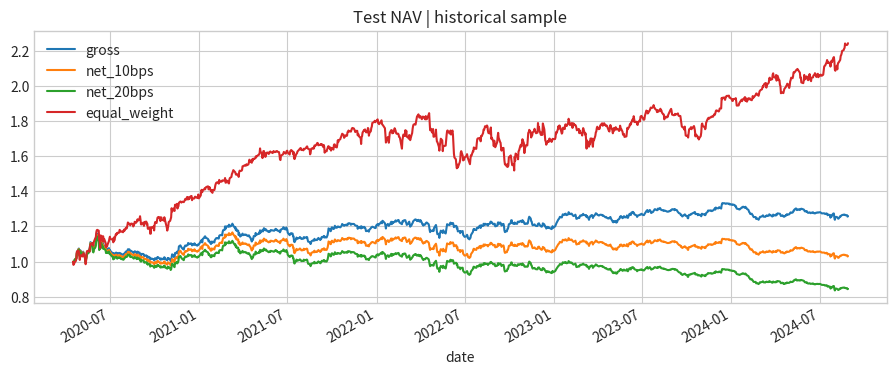

In [31]:
benchmark = test.groupby("date")["target"].mean().reindex(bt.index)
def performance(ret: pd.Series) -> dict:
    ret = ret.dropna()
    nav = (1 + ret).cumprod()
    if (1 + ret <= 0).any():
        raise ValueError("收益 <= -100%，净值定义失效")
    ann = nav.iloc[-1] ** (252 / len(ret)) - 1
    vol = ret.std(ddof=1) * np.sqrt(252)
    sharpe = ret.mean() / ret.std(ddof=1) * np.sqrt(252) if ret.std(ddof=1) > 0 else np.nan
    drawdown = nav / nav.cummax() - 1
    return {"累计收益": nav.iloc[-1] - 1, "年化收益": ann, "年化波动": vol,
            "夏普(无风险=0)": sharpe, "最大回撤": drawdown.min()}
results = pd.DataFrame({
    "多空毛收益": performance(bt0["net"]),
    "多空净收益10bps": performance(bt["net"]),
    "多空净收益20bps": performance(bt20["net"]),
    "等权基准(未扣成本)": performance(benchmark),
}).T
display(results.round(3))
print("平均单期换手:", round(bt.turnover.mean(), 3), "；累计成本(简单求和):", round(bt.cost.sum(), 3))
curves = pd.DataFrame({
    "gross": (1 + bt0.net).cumprod(), "net_10bps": (1 + bt.net).cumprod(),
    "net_20bps": (1 + bt20.net).cumprod(), "equal_weight": (1 + benchmark).cumprod()
})
curves.plot(figsize=(11, 4), title="Test NAV | historical sample")
plt.show()

### 相对收益与信息比率

超额收益应对齐同一期基准；信息比率 = 平均主动收益 / 主动收益标准差 × √252。它与夏普不同：夏普参照无风险收益，信息比率参照一个可投资基准。市场中性策略与多头基准风险不同，因此同一个数字也要交代可比性。

In [32]:
active_return = bt.net - benchmark
information_ratio = active_return.mean() / active_return.std(ddof=1) * np.sqrt(252)
print("相对等权基准的信息比率:", round(information_ratio,3))
assert np.isfinite(information_ratio)

相对等权基准的信息比率: -1.373


### Calmar：不要把宣传门槛当研究目标

Calmar = 同一评价窗口的复合年化收益 / 最大回撤绝对值。回撤接近零时比值可能不稳定；改变窗口和估值频率也会改变数字。图三写的“Calmar 超过 3”是未经本项目验证的结果主张，**不是 MiniQuant 必须达成的目标**；筛选参数去凑门槛会造成回测过拟合。

In [33]:
calmar = results["年化收益"] / results["最大回撤"].abs().replace(0, np.nan)
display(calmar.rename("同测试期 Calmar").to_frame().round(3))
assert np.isfinite(calmar.dropna()).all()

,同测试期 Calmar
多空毛收益,0.397
多空净收益10bps,0.045
多空净收益20bps,-0.141
等权基准(未扣成本),1.149


### Alpha / Beta 归因
以每日基准收益回归策略净收益：斜率为 beta，截距日化再乘 252 是粗略 alpha。这里仅用于理解线性归因；截距不能证明真实超额收益，显著性还受自相关、共同暴露和样本选择影响。对零净敞口多空策略，beta 仍可能不为零。

beta=0.400; 粗略年化 alpha=-6.661%


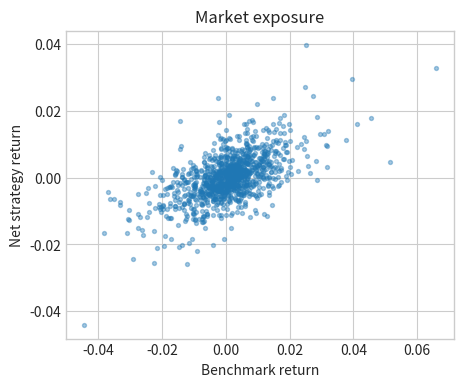

In [34]:
x = benchmark.to_numpy()
y = bt["net"].to_numpy()
beta, alpha_daily = np.polyfit(x, y, deg=1)
print(f"beta={beta:.3f}; 粗略年化 alpha={alpha_daily*252:.3%}")
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, s=8, alpha=0.4)
ax.set(xlabel="Benchmark return", ylabel="Net strategy return", title="Market exposure")
plt.show()

## 专题 D：聚类是探索工具，不是自动交易信号
KMeans 依靠距离与预设簇数；DBSCAN 按密度识别簇和噪声，不必指定簇数。距离对量纲很敏感，因此只用训练期的收益分布特征并标准化。聚类可帮助观察风险风格，不代表簇标签可预测未来。

,mean,vol,skew,kmeans,dbscan
ticker,,,,,
ADSK,0.001,0.023,-0.022,0,0
AKAM,0.001,0.024,0.750,0,0
AMZN,0.001,0.020,0.393,0,0
CBRE,0.001,0.022,-0.053,0,0
CMG,0.001,0.022,0.568,0,0
...,...,...,...,...,...
WELL,0.000,0.017,-0.885,1,0
WMT,0.000,0.012,0.536,1,0
WST,0.001,0.015,0.574,1,0


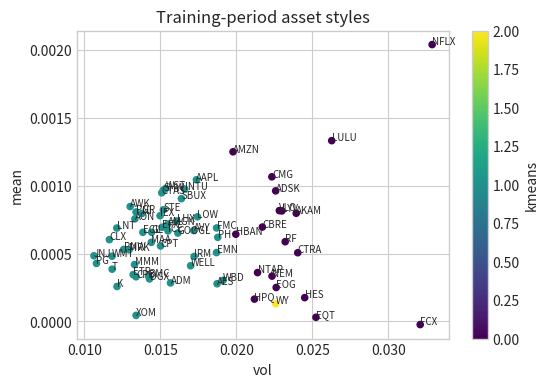

In [35]:
from sklearn.cluster import KMeans, DBSCAN
train_returns = close_ret.loc[:train.date.max()]
asset_stats = pd.DataFrame({"mean": train_returns.mean(),
                            "vol": train_returns.std(),
                            "skew": train_returns.skew()}).dropna()
scaled = StandardScaler().fit_transform(asset_stats)
asset_stats["kmeans"] = KMeans(n_clusters=3, random_state=SEED, n_init=10).fit_predict(scaled)
asset_stats["dbscan"] = DBSCAN(eps=1.1, min_samples=2).fit_predict(scaled)
display(asset_stats.sort_values("kmeans").round(3))
ax = asset_stats.plot.scatter("vol", "mean", c="kmeans", colormap="viridis", figsize=(6, 4), title="Training-period asset styles")
for name, row in asset_stats.iterrows():
    ax.annotate(name, (row.vol, row["mean"]), fontsize=7)
plt.show()

**追问**：DBSCAN 的 -1 表示什么？KMeans 改变 k 或标准化方法，哪些股票换了簇？如果把测试期收益也拿来聚类再回测，哪里发生了泄漏？

## 11. 红队审计：主动让自己失败
1. 数据：当前成分股是否回看历史？退市、分红、拆股、时区、复权是否正确？
2. 时间：每个字段何时发布、何时可交易？训练标签什么时候真正可得？
3. 交易：能否成交、能否借券、成本是否随订单规模增加？
4. 统计：尝试多少因子和参数？是否只展示最漂亮的一次？测试集是否被反复使用？
5. 稳健：换一段时间、股票池、成本、持有期，结果是否稳定？

下面两项故意演示假象，**绝不用于正式策略**。

In [36]:
# 故意把答案当分数：IC 必然为 1，说明任何异常漂亮的结果要先排查泄漏。
leaky = test.assign(leaked_score=test["target"])
print("泄漏演示 IC:", daily_ic(leaky, "leaked_score").mean())
# 多重试验：纯噪声中挑最大值，也能出现看似漂亮的数字。
noise_ics = []
for trial in range(50):
    temp = test.assign(noise_score=rng.normal(size=len(test)))
    noise_ics.append(daily_ic(temp, "noise_score").mean())
print("50 个噪声信号：平均 IC", round(np.mean(noise_ics), 4),
      "；只报最好的 IC", round(np.max(noise_ics), 4))

泄漏演示 IC: 1.0


50 个噪声信号：平均 IC 0.0001 ；只报最好的 IC 0.0075


### 敏感性检查
成本假设应覆盖有利与不利情景；结果若只在零成本下成立，研究结论应写为“成本敏感”。这仍不能代替逐笔成交与订单簿数据。

In [37]:
sensitivity = pd.DataFrame({
    f"{bps} bps": performance(run_backtest(weights, bps)["net"])
    for bps in [0, 5, 10, 20, 40]
}).T
display(sensitivity[["年化收益", "夏普(无风险=0)", "最大回撤"]].round(3))

,年化收益,夏普(无风险=0),最大回撤
0 bps,0.054,0.524,-0.136
5 bps,0.030,0.321,-0.144
10 bps,0.007,0.117,-0.153
20 bps,-0.038,-0.289,-0.271
40 bps,-0.122,-1.102,-0.501


### KMeans 的一次手工迭代

初始化两个中心；把每个样本分给最近中心，再把中心更新为簇内均值，重复至分配不再变化。距离和标准化决定结果；DBSCAN 则用半径 `eps` 和最少邻居数形成密度簇，标签 `-1` 表示噪声。下面用训练期资产的真实统计量演示中心更新，不把聚类标签当作预测信号。

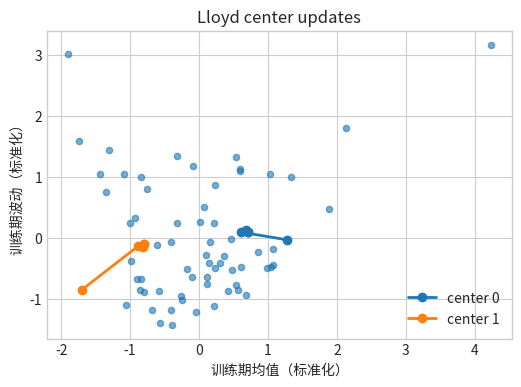

In [38]:
points = scaled[:, :2]
centers = points[[0, -1]].copy()
history = [centers.copy()]
for _ in range(5):
    assignment = ((points[:,None,:] - centers[None,:,:])**2).sum(axis=2).argmin(axis=1)
    updated = np.vstack([points[assignment==j].mean(axis=0) if (assignment==j).any() else centers[j]
                         for j in range(2)])
    history.append(updated.copy())
    if np.allclose(updated, centers): break
    centers = updated
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(points[:,0], points[:,1], s=20, alpha=.6)
path = np.stack(history)
for j in range(2): ax.plot(path[:,j,0], path[:,j,1], "o-", lw=2, label=f"center {j}")
ax.set(xlabel="训练期均值（标准化）", ylabel="训练期波动（标准化）", title="Lloyd center updates")
ax.legend(); plt.show()

## 专题 E：Prophet 时间序列预测与趋势转折
原始参考课的 Prophet 部分用单股价格说明 ds/y 格式、趋势、季节性、changepoint_prior_scale 调参和未来框架。这里用真实 AMZN 复权收盘价做**单资产预测教学**：只用 2010–2022 拟合、2023 验证，比较“明天等于今天”的朴素基线。预测价格不是选股信号，更不等于可交易收益。Prophet 的区间主要表达模型不确定性，不能当严格市场置信区间。

In [39]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
amzn = bars[bars.ticker == "AMZN"][ ["date", "adj_close"] ].rename(columns={"date": "ds", "adj_close": "y"})
train_price = amzn[amzn.ds < "2023-01-01"]
valid_price = amzn[(amzn.ds >= "2023-01-01") & (amzn.ds < "2024-01-01")]
forecast_rows = []
for prior in [0.01, 0.05]:
    forecaster = Prophet(changepoint_prior_scale=prior, yearly_seasonality=False,
                         weekly_seasonality=False, daily_seasonality=False)
    forecaster.fit(train_price)
    pred = forecaster.predict(valid_price[["ds"]])["yhat"].to_numpy()
    forecast_rows.append((prior, mean_absolute_error(valid_price.y, pred)))
naive = mean_absolute_error(valid_price.y, np.repeat(train_price.y.iloc[-1], len(valid_price)))
print("验证集 MAE (美元):", forecast_rows, "；固定末值基线:", round(naive, 2))
print("说明：此处是 2023 全年一次性预测，不是逐日滚动交易信号。")

19:14:14 - cmdstanpy - INFO - Chain [1] start processing


19:14:14 - cmdstanpy - INFO - Chain [1] done processing


19:14:14 - cmdstanpy - INFO - Chain [1] start processing


19:14:15 - cmdstanpy - INFO - Chain [1] done processing


验证集 MAE (美元): [(0.01, 30.017906203751505), (0.05, 18.59028343384654)] ；固定末值基线: 37.38
说明：此处是 2023 全年一次性预测，不是逐日滚动交易信号。


**练习**：画出预测值与真实值；将训练截止改为 2021 年底，观察误差变化。调参只能使用验证期，不能看完 2024 测试结果再挑一个最好的 prior。Prophet 的趋势转折点越灵活，训练拟合可能越好，外推也可能更差。

## 12. 更换数据源：研究任务清单
本项目的行情下载、验证与 Parquet 快照见 `tools/build_real_snapshot.py` 和第 2 章；因子、模型、回测与审计见后续章节。旧参考资料的主题迁移清单见 `tools/COVERAGE.md`，其中的历史收益数值不作为本 Notebook 结果的独立验证。

真实数据适配的最低要求：
1. 每行 date、ticker、原始 open/high/low/close、adj_close、volume；若可得到真实 adjusted open 则优先用它。否则用 adjusted_open = raw_open × adj_close/raw_close，并检查公司行动日的成交与收益处理。**不要将复权收益与原始开盘价混算。**
2. 必须有逐日历史股票池、退市股票、可交易状态、停牌和交易日历；当前指数成分股回测历史只能作为教学例子。
3. 对财务、分析师和另类数据，存储“发布日期、可用时间、修订版本”，使用当时可见版本；避免事后修订泄漏。
4. 数据快照、代码版本、参数、随机种子、币种、时区和费用假设写进实验日志。
5. 免费数据源可能限流、修订或缺字段；下载失败要报错，不能静默用更短的样本代替。

**可操作练习**：用 quant-tutorial/01-data-foundation 的日行情 parquet 构建相同字段，再逐项运行 validate_bars；先只读数据，不覆盖参考仓库。该仓库当前可能只有 adj_close 而无可靠 adjusted open，补齐并验证前，不能直接拿本文的开盘回测宣称真实结果。

In [40]:
def load_real_bars(path: str) -> pd.DataFrame:
    """只读导入用户授权的日频 Parquet；不下载、不改源文件。"""
    raw = pd.read_parquet(path)
    needed = {"date", "ticker", "open", "high", "low", "close", "adj_close", "volume"}
    missing = needed - set(raw.columns)
    if missing:
        raise ValueError(f"行情字段缺失: {missing}")
    raw = raw.copy()
    raw["date"] = pd.to_datetime(raw["date"]).dt.tz_localize(None)
    if raw[list(needed)].isna().any().any():
        raise ValueError("原始行情存在缺失，须先调查，不能静默填补")
    if (raw["close"] <= 0).any():
        raise ValueError("原始收盘价非正")
    factor = raw["adj_close"] / raw["close"]
    if (factor <= 0).any() or not np.isfinite(factor).all():
        raise ValueError("复权比例异常")
    raw["adj_open"] = raw["open"] * factor
    raw["high"] = raw["high"] * factor
    raw["low"] = raw["low"] * factor
    result = raw[["date", "ticker", "adj_open", "adj_close", "high", "low", "volume"]]
    result = result.sort_values(["date", "ticker"]).reset_index(drop=True)
    validate_bars(result)
    return result

# 仅在已下载并审计真实行情后手动运行；替换第 2 节的 bars，再从第 3 节重新运行。
# path = "data/your_authorized_daily.parquet"
# bars = load_real_bars(path)
# dates = pd.DatetimeIndex(sorted(bars["date"].unique()))
# tickers = sorted(bars["ticker"].unique())
# 注意：真实数据有缺失交易日、停牌、退市；必须重写对齐与可交易性规则后才可作正式回测。

## 专题 F：从课堂到真实研究流程
每日定时器并不是“每天自动盈利”：它在收盘后采集快照、校验、生成分数，在下一可成交时刻发订单，再把实际成交、成本和异常写入日志。股票池要按日期还原，先过滤当时不可交易、价格异常与流动性不足的证券。策略上线前做纸面交易、监控数据缺口与漂移，出现异常时停止发单。当前 Notebook 是研究型回测，没有接券商 API；切勿把示例订单逻辑直接用于实盘。

### AI 辅助学习法（吸收参考仓库的 00 课与对话指南）
每章按“先解释概念 → 你提出需求 → 代码运行 → 故意造错 → 验收追问”学习。让 AI 先讲明白时间线和失败条件，再让它写代码；遇到报错先看最后一行和输入样例；请它用测试和反例验证答案。参考工具可用 Codex、Claude 或其他助手，重点是你能独立判断数据、因果和结果，不能只复制成功输出。

# 第二篇：A 股盘口、逐笔与量化模型岗

![信息可得性时间线](figs/02_availability_timeline.png)

日线课程教你建立正确研究流程；本篇把数据粒度推进到**快照（snapshot）、逐笔委托（order）、逐笔成交（trade）**。上交所 Level-2 产品可提供十档价量、第一档排队委托量、逐笔成交及订单关联信息；历史产品的数据范围和授权需核对供应商协议。**这些数据不是免费的普遍公开样本**，本项目不冒充持有机构全市场数据。下方小事件表是明确标记的教学夹具，只验证算法和边界；接入真实数据的字段合同与验收规则同样给出。参见[上证所 Level-2](https://www.sseinfo.com/services/assortment/level2/)与[历史数据接口说明](https://www.sseinfo.com/services/assortment/historical/)。

## 盘口术语和数据契约

| 层级 | 典型字段 | 能回答什么 | 特别检查 |
|---|---|---|---|
| L1/十档快照 | event_time、receive_time、bid/ask 1–10 价量、累计量额 | 当时可见流动性、价差、深度 | 档位单调、交叉盘、停牌/集合竞价、快照间丢包 |
| 逐笔委托 | 证券、通道、序号、订单号、方向、价格、数量、委托/撤单类型 | 排队、补单与撤单 | 序号连续性、撤单找不到原单、版本差异 |
| 逐笔成交 | 成交序号、价格、数量、买卖订单号、标志 | 主动性、成交冲击、订单剩余量 | 关联缺失、集合竞价与特殊成交 |

交易所**事件时间**、供应商到达时间、研究系统接收时间必须分开保存；先按交易所/通道的序列规则处理，不能仅按毫秒时间戳盲排。不同交易所和接口版本的消息类型/订单号语义不同，重建前用官方数据字典做适配。价格使用整数 tick 或定点数、数量用整数股；不要让浮点误差决定撮合。落库主键至少含交易日、市场、证券、通道、消息序号；原始包只读、派生表可重建。

## 一个可审计的微型订单簿（教学夹具，非真实行情）

下表只模拟连续竞价中单一证券的**限价买单新增与撤单**，不模拟完整交易所撮合，也不代表 A 股历史事实。先学事件应用：新增增加该价位剩余量，撤单只减少存在的订单，任何负剩余量、重复订单号、乱序都必须失败。真实系统还需卖盘、成交拆分、改价、集合竞价、交易状态、通道合并和快照校准。

In [41]:
events = pd.DataFrame([
    (1, "add", "B001", "buy", 1000, 600),
    (2, "add", "B002", "buy", 999, 400),
    (3, "add", "B003", "buy", 1000, 300),
    (4, "cancel", "B001", "buy", 1000, 200),
], columns=["seq", "kind", "order_id", "side", "price_tick", "qty"])
orders = {}
for e in events.itertuples(index=False):
    if e.kind == "add":
        if e.order_id in orders: raise ValueError("重复订单号")
        orders[e.order_id] = [e.side, e.price_tick, e.qty]
    elif e.kind == "cancel":
        if e.order_id not in orders or e.qty > orders[e.order_id][2]:
            raise ValueError("无法匹配或超量撤单")
        orders[e.order_id][2] -= e.qty
depth = {}
for side, price_tick, qty in orders.values():
    depth[(side, price_tick)] = depth.get((side, price_tick), 0) + qty
display(events)
print("剩余买盘档位（price_tick → 股数）:", depth)
assert depth[("buy", 1000)] == 700

,seq,kind,order_id,side,price_tick,qty
0,1,add,B001,buy,1000,600
1,2,add,B002,buy,999,400
2,3,add,B003,buy,1000,300
3,4,cancel,B001,buy,1000,200


剩余买盘档位（price_tick → 股数）: {('buy', 1000): 700, ('buy', 999): 400}


### 真实 Level-2 数据接入门槛

同一字段名在沪深不同版本可能有不同语义。接到真实 CSV/二进制流时，先形成**适配层**：接口文档版本、市场/证券/交易日、事件类型、原始消息序号、交易所事件时间、接收时间、价格精度、数量单位、订单关联。只读保留原始记录；转换写入临时分区，核对记录数、序号缺口、重复键、负价负量、盘口交叉和成交量/额；通过后才发布派生快照。A 股真实数据还需注意午间停盘、集合竞价、临停、除权除息、涨跌幅和交易所规则的历史版本。以下函数示范**字段门禁**，不能把通过门禁等同于完整清洗。

In [42]:
def validate_l2_event_schema(frame: pd.DataFrame) -> None:
    required = {"market", "trading_date", "symbol", "channel", "seq", "event_time", "event_type", "price_tick", "qty"}
    missing = required - set(frame.columns)
    if missing: raise ValueError(f"缺少 L2 字段: {sorted(missing)}")
    if frame.duplicated(["market","trading_date","symbol","channel","seq"]).any():
        raise ValueError("消息主键重复")
    if (frame.qty < 0).any() or (frame.price_tick < 0).any():
        raise ValueError("负价格或负数量")
    if not frame.sort_values(["market","trading_date","symbol","channel","seq"]).index.equals(frame.index):
        raise ValueError("消息未按通道序号排列")
fixture = events.rename(columns={"kind":"event_type"}).copy()
fixture["market"]="SZSE"; fixture["trading_date"]="2025-01-02"; fixture["symbol"]="DEMO.SZ"
fixture["channel"]=1; fixture["event_time"]=["09:30:00.010","09:30:00.020","09:30:00.030","09:30:00.040"]
validate_l2_event_schema(fixture.reset_index(drop=True))
print("教学夹具字段门禁通过；真实数据还需重放与官方快照核对")

教学夹具字段门禁通过；真实数据还需重放与官方快照核对


## 高频因子：定义、延迟和反证

快照因子：**盘口不平衡** $I=(B_1-A_1)/(B_1+A_1)$、价差 bps、十档深度、微观价格 $p_{micro}=(a_1 B_1+b_1 A_1)/(B_1+A_1)$。逐笔因子：订单流不平衡（OFI）、主动买卖量差、撤单率、排队消耗率、大单行为。它们都有微观机制，但高频预测半衰期短；交易延迟、手续费、冲击、涨跌停和盘口隐藏流动性可能抹掉表面 alpha。盘口价量是**观察值**，不能把快照中的卖一量直接当作自己可成交量。

每个因子写四行：数学定义、事件/快照时点、缺失/异常处理、理论反例。分桶按股票和时段做，比较集合竞价、开盘、午后、尾盘；避免把全日均值泄漏到上午。先做秒级到分钟级聚合，再问是否适合日频横截面预测。

In [43]:
book = pd.DataFrame({"bid1": [9.99,10.00,10.00,9.99], "ask1": [10.00,10.01,10.01,10.00],
                     "bid_qty1": [5000,6500,4000,3000], "ask_qty1": [3000,2500,4500,6000]},
                    index=pd.to_datetime(["2024-01-02 09:30:00", "2024-01-02 09:30:03", "2024-01-02 09:30:06", "2024-01-02 09:30:09"]))
# 教学夹具：仅用于公式单元测试，不是市场实测结果。
book["mid"] = (book.bid1 + book.ask1) / 2
book["imbalance"] = (book.bid_qty1 - book.ask_qty1) / (book.bid_qty1 + book.ask_qty1)
book["spread_bps"] = (book.ask1 - book.bid1) / book.mid * 10000
book["microprice"] = (book.ask1 * book.bid_qty1 + book.bid1 * book.ask_qty1) / (book.bid_qty1 + book.ask_qty1)
display(book.round(5))
assert book.imbalance.between(-1,1).all()

,bid1,ask1,bid_qty1,ask_qty1,mid,imbalance,spread_bps,microprice
2024-01-02 09:30:00,9.99,10.00,5000,3000,9.995,0.25000,10.005,9.99625
2024-01-02 09:30:03,10.00,10.01,6500,2500,10.005,0.44444,9.995,10.00722
2024-01-02 09:30:06,10.00,10.01,4000,4500,10.005,-0.05882,9.995,10.00471
2024-01-02 09:30:09,9.99,10.00,3000,6000,9.995,-0.33333,10.005,9.99333


### 从快照变化估算订单流不平衡（OFI）

以相邻快照的买一价量与卖一价量变化构造 OFI：买价上升加新买量、相等加买量变化、下降减旧买量；卖侧按相反符号处理。它是快照版近似，不能代替逐笔事件的真实新增/撤单净量；若两个快照之间多次价格跳动，信息已经丢失。

In [44]:
def snapshot_ofi(q: pd.DataFrame) -> pd.Series:
    old = q.shift(1)
    buy = np.where(q.bid1 > old.bid1, q.bid_qty1,
          np.where(q.bid1 == old.bid1, q.bid_qty1-old.bid_qty1, -old.bid_qty1))
    sell = np.where(q.ask1 < old.ask1, q.ask_qty1,
           np.where(q.ask1 == old.ask1, q.ask_qty1-old.ask_qty1, -old.ask_qty1))
    return pd.Series(buy-sell,index=q.index,name="snapshot_OFI").iloc[1:]
display(snapshot_ofi(book).to_frame())
print("注意：这是 4 行教学快照的公式检查，没有统计显著性。")

,snapshot_OFI
2024-01-02 09:30:03,9500.0
2024-01-02 09:30:06,-4500.0
2024-01-02 09:30:09,-10000.0


注意：这是 4 行教学快照的公式检查，没有统计显著性。


## 非时间轴：时间、笔数、成交量与成交金额

![四种采样轴对照](figs/04_sampling_axes.png)

时钟 Bar 每隔固定分钟结束；Tick Bar 每固定成交笔数结束；Volume Bar 每累计固定股数结束；Dollar Bar 每累计固定成交金额结束。后者在活跃时更频繁、冷清时更稀疏，改变了“一个样本”的定义。阈值只能用训练期估计，不能为了测试收益反复调；采样不能抹掉原始事件时间，仍需按 `available_at` 连接公告与盘口特征。图中的 **C₁ 自定义轴没有定义式或原始代码**，本课不猜其含义；下面给出可核对的成交金额轴。

参考原始研究：[Easley、López de Prado、O’Hara 的 Volume Clock](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2034858)。

In [45]:
# 教学逐笔表：人为构造，只检验“何时结束一根 Bar”的算法。
toy_trades = pd.DataFrame({
    "time": pd.date_range("2024-01-02 09:30:00", periods=18, freq="11s"),
    "price": [10,10.01,10.01,10.02,10.02,10.03,10.03,10.02,10.01,
              10.00,10.01,10.02,10.03,10.04,10.04,10.03,10.02,10.01],
    "qty": [100,150,80,200,120,180,90,240,160,100,300,80,170,130,220,110,190,140]})
toy_trades["notional"] = toy_trades.price * toy_trades.qty
def make_dollar_bars(trades: pd.DataFrame, threshold: float) -> pd.DataFrame:
    if threshold <= 0: raise ValueError("threshold 必须为正")
    rows=[]; bucket=[]; cash=0.0
    for row in trades.itertuples(index=False):
        bucket.append(row); cash += row.notional
        if cash >= threshold:
            prices=[x.price for x in bucket]
            rows.append({"end_time":row.time,"open":prices[0],"high":max(prices),
                         "low":min(prices),"close":prices[-1],"qty":sum(x.qty for x in bucket),
                         "notional":cash,"trade_count":len(bucket)})
            bucket=[]; cash=0.0
    # 未满门槛的末尾事件不输出；跨日重置与否必须成为显式策略。
    return pd.DataFrame(rows)
dollar_bars = make_dollar_bars(toy_trades, threshold=3000)
display(dollar_bars)
assert (dollar_bars.notional >= 3000).all()
assert dollar_bars.end_time.is_monotonic_increasing

,end_time,open,high,low,close,qty,notional,trade_count
0,2024-01-02 09:30:22,10.00,10.01,10.00,10.01,330,3302.3,3
1,2024-01-02 09:30:44,10.02,10.02,10.02,10.02,320,3206.4,2
2,2024-01-02 09:31:17,10.03,10.03,10.02,10.02,510,5112.9,3
3,2024-01-02 09:31:50,10.01,10.01,10.00,10.01,560,5604.6,3
4,2024-01-02 09:32:23,10.02,10.04,10.02,10.04,380,3811.9,3
5,2024-01-02 09:32:45,10.04,10.04,10.03,10.03,330,3312.1,2
6,2024-01-02 09:33:07,10.02,10.02,10.01,10.01,330,3305.2,2


**轴与特征的关系**：Dollar Bar 是采样/聚合方式，盘口不平衡是特征，两者可组合。若在 Dollar Bar 上算“过去 3 根的收益”，对应实际历时会变动；若要与时钟模型融合，先按决策时刻对齐。样本数少不能声称 Bar 收益比时钟收益更正态；只可报告同训练/测试切分下的偏度、尾部、预测与成本指标。

In [46]:
from scipy.stats import entropy
bar_sign = np.sign(dollar_bars.close.diff().dropna())
counts = bar_sign.value_counts(normalize=True)
print("教学 Dollar Bar 收益方向熵(bit):", round(float(entropy(counts, base=2)), 3))
print("每根 Bar 的实际历时(秒):", dollar_bars.end_time.diff().dt.total_seconds().dropna().tolist())
assert dollar_bars.trade_count.sum() <= len(toy_trades)

教学 Dollar Bar 收益方向熵(bit): 1.459
每根 Bar 的实际历时(秒): [22.0, 33.0, 33.0, 33.0, 22.0, 22.0]


## 模型岗：从盘口因子到可复现训练

1. **目标**：定义 t 决策、实际到达 t+Δ、持有 h 的 mid-price return 或可成交收益；标签先扣半价差、延迟与交易费。三分类（上/平/下）阈值只能从训练期确定。
2. **切分**：按交易日与证券分组，留出完整未来日期；标签重叠需 purge/embargo，跨股同日共享市场冲击，不能随机按行打散。标准化、缺失填充、特征筛选只在训练期拟合。
3. **基线**：零预测、盘口不平衡单因子、Logistic/Ridge；再比较 GBDT/LightGBM、序列模型（CNN/LSTM/Transformer）。报告 IC、AUC/校准、扣成本收益及容量；AUC 更高不必然策略更好。
4. **训练**：目标函数、样本权重、类别不平衡、时段/股票分层、超参搜索预算、随机种子、模型和数据版本。做特征消融、时段消融、延迟/成本敏感性、市场状态外推。
5. **上线**：离线与在线特征同构，监控数据延迟、缺失、分布漂移、成交偏差；设置回退基线与停机条件。

来自 LLM 的经验可迁移到实验管理、分布式训练和模型评测，但金融标签低信噪比、非平稳、反馈有交易成本；“训练 loss 下降”不等于可盈利。

### 二级决策模型（meta-labeling）放在什么位置？

一级模型给方向或候选交易；二级模型只判断“这笔候选是否值得做/做多大”，可以纳入价差、队列、信号置信度和风险限额。训练二级模型时，一级分数必须来自当时可得的**滚动样本外预测**；把一级模型在自身训练集上的拟合分数拿来训练二级模型会再次泄漏。二级模型的增益要用扣成本和同一订单约束检验，不以宣传材料声称的 Calmar 为目标。

### 实时推理与策略安全边界

离线训练产物要包含模型、预处理器、特征 schema、训练结束时间和版本哈希。在线流程依次检查**消息序号 → 事件时间/接收时间 → 特征完整性 → 推理耗时 → 信号有效期 → 交易限制 → 订单状态回报**。超时或缺字段应丢弃信号/退回预设安全基线，不能盲目用旧盘口。研究回放能证明状态机对给定事件正确，却不能证明生产环境排队、网络、风控和券商行为一致。

为 ETF、股指期货、商品期货迁移模型时，要重新定义交易单位、保证金/杠杆、合约到期与换月、交易时段和可卖空性；不能把股票的标签、成交与成本原样套用。所谓“通用模型”需要跨标的、跨市场状态的样本外证据；“专用模型”也要防止只记住单只股票。

### 第三关验收：从数据到策略的 12 个问题

1. 原始事件是否有缺口、重复、乱序、修订？2. 非时间 Bar 何时结束，未结束 Bar 能否使用？3. 决策时间、接收时间和可成交时间是否不同？4. 金融机制与纯数学变换能否区分？5. 标签密度和持有窗口如何影响样本独立性？6. purge/embargo 删掉了哪些训练事件？7. PCA 在上线时还需要哪些原始列？8. 模型融合是否真的增加独立信息？9. 目标权重如何变成部分成交的持仓？10. 成本与订单规模上升时结果如何变化？11. 哪些情形触发停止发单？12. 实验记录能否复现所有试过的参数，而非只展示最好的一次？

**验收方式**：每题写出一个定义、一个失败反例、一个可运行检查。图三的业绩数字不作为通过条件。

## 因子岗与策略岗：各交一份可复核作品

**因子岗作品**：给出订单簿重建的消息合同与异常计数；以盘口不平衡/OFI 为例列数学定义与因果时间线；展示分时段 IC、分组收益、换手、延迟和成本曲线；对齐原始包、派生数据和因子版本。高频数据的数据库维护包括分区、索引、去重、压缩、重放、质量告警和权限审计。

**策略岗作品**：从股票池与交易日历出发，生成点时特征→预测→目标权重→订单→成交→持仓→净值；考虑不可交易、涨跌停、订单部分成交、撤单、T+1/卖出资格、资金、风控、容量。先给事件驱动的接口设计，再用历史重放做单元与场景测试。研究回测、纸面交易与实盘应共用核心订单状态机，不应把每日目标权重直接当成实际成交。

## 延伸工具箱：把 whale-quant 的广度放在正确层级

| 主题 | 必须理解的核心 | MiniQuant 中的实践/边界 |
|---|---|---|
| 数据源 | Baostock/TuShare 的访问、字段、复权、财报公告日；技术面/基本面 | 本项目冻结真实日行情；替换 A 股数据需重建点时股票池，不硬编码 token |
| 选股 | MPT、CAPM、APT、因子 IC、暴露、中性化 | 日频横截面与组合章节 |
| 择时 | 异常、趋势、均线、MACD、资金、情绪、SVM/SWARCH/Hurst | 均线实做；其余以“假设→时间验证”方式扩展 |
| 配置 | 等权、市值、最小方差、最大分散度、风险平价、均值—方差、有效前沿、约束 | 上方训练期优化；不能用未来均值/协方差 |
| 回测 | 手写事件引擎与 JoinQuant/Backtrader/BigQuant 类框架的共同逻辑 | 本项目透明实现；框架 API 随版本变化需查文档 |
| 机器学习 | 回归/分类、SVM、LightGBM、时间序列、小波、LSTM 与非结构化新闻 | 先以 Ridge 和 Prophet 建基线，再按任务增加复杂度；新闻要按发布时间入库 |

这张表不是“看过就掌握”。每个扩展模型都需复制相同时间线、基线、成本与失败检验；对实习模型岗，先把数据和验证做对，比堆算法名更重要。

![回测偏差对照表](figs/03_backtest_bias_checks.png)

**自测**：把 A 股真实逐笔文件交给你时，先问哪 10 个字段和质量指标？为什么时间戳相同不代表消息顺序相同？为什么盘口不平衡的 IC 为正也可能亏钱？怎样证明模型优于一个无需训练的盘口基线？怎样把模型输出变成实际成交？能独立口述并展示代码，才算这一篇完成。

## 13. 实习面试与作品集：把“会跑”变成“会解释”
建议交付一个短报告和可复现代码，包含：
- 研究问题与事先写好的假设；说明为什么因子可能预测未来，什么证据会推翻它。
- 数据字典、覆盖率、异常样例、历史股票池和点时可得性图。
- 时间线、训练/验证/测试日期、purge 长度、特征表与标签定义。
- 动量和等权基线、Ridge 模型、逐日 IC 分布、分层收益与模型系数。
- 毛/净收益、成本曲线、换手、回撤、市场暴露、容量和失败场景。
- 实验日志：所有尝试过的窗口、模型和参数；最后一次独立测试结果。

面试自测：① 为什么标签可以看未来，特征不可以？② 为什么收盘后信号不能同收盘成交？③ 分红如何影响收益？④ 随机切分与无 purge 会怎样？⑤ IC 高但净收益差，先查什么？⑥ 回测很好时如何排查幸存者偏差和多重试验？⑦ 多空与纯多头的风险和融资要求有何不同？

**进阶路线**：walk-forward 重训、行业与市值中性化（只用当时可得暴露）、组合约束与优化、开盘竞价与冲击成本、退市和停牌处理、事件驱动引擎、统计置信区间及多重检验校正。做到这些并能清楚讲出局限，比背一个漂亮夏普更接近实习工作。

## 14. 可选的 500 元实盘实验：先学会不被交易界面牵着走

**这不是收益承诺或针对个人的投资建议。** 500 元涨到 800 元意味着本金收益 **60%**，在未指定期限、风险和基准的情况下，不能把它设为合格线；为了追这个数字去频繁交易、碰高杠杆或集中押注，正是初学者容易付学费的方式。真正可检验的“毕业标准”是：独立核验正规账户、正确下单、理解成交和撤单、计算含费用的盈亏、留下交易日志、遵守事先的最大亏损与停止规则。亏钱但纪律完整，也比侥幸赚到 60% 更有学习价值。

**手机 App 怎么选：** 先到[证监会证券经营机构公示](https://www.csrc.gov.cn/csrc/c101860/c1022458/content.shtml)核对券商主体，再从券商**自己的官网**进入下载页，核对开发者和账户主体。例如[华泰证券官网的“涨乐财富通”](https://www.htsc.com.cn/browser/mobile/mobileSecurities/SoftwareDownload.jsp)、[中国银河证券官网 App 下载中心](https://www.chinastock.com.cn/newsite/online/downloadCenter.html)、[国信证券官网“金太阳”](https://www.guosen.com.cn/gxzq/openaccount/prompt_jty.jsp)都提供官方入口。这是核验入口示例，不是按收益或服务质量排名，也不鼓励同时开多个账户。实际选择看本人开户资格、费率表、**每笔最低佣金**、ETF 费率、交割单可导出性、客服与风险提示；不要从聊天群链接下载“内部版”或把验证码交给所谓老师。

**为什么优先用宽基、非杠杆的境内股票 ETF 做“操作实验”，而不是推荐一只股票？** 单只股票的公司风险集中，而宽基 ETF 包装一篮子股票，更适合用极小资金学习证券订单和组合风险。不过 ETF 仍会亏损，可能有溢折价、跟踪误差，且 500 元无法充分分散。上交所和深交所投教资料均说明，ETF 二级市场买入通常以 **100 份**为最小单位；境内股票 ETF 当日买入通常次日才能卖出，其他 ETF 品种规则可能不同。研究与实盘前必须按具体代码、交易所和当天有效规则核对。[上交所 ETF 规则问答](https://edu.sse.com.cn/service/hotline/qa/c/4956495.shtml) · [深交所 ETF 入门](https://investor.szse.cn/warning/activities/fundIntroduction/t20210104_584079.html)


### 一次完整的、可以放弃交易的操作流程

1. **先用模拟盘或纸面记录 5 个交易日。** 每天写下想买什么、为什么、限价多少、何时撤单、费用多少。没有清楚的理由就不交易。
2. **开户前核验。** 本人实名开立普通证券账户，绑定本人银行卡；核对开户协议、适当性与费用，不开融资融券、期权、期货等杠杆权限。不同券商对小额订单的最低佣金不同，向客服取得实际费率表或在交割单确认。
3. **转入 500 元，先保留至少 100 元现金。** 在 App 输入证券代码时核对完整名称、交易所、是否境内宽基股票 ETF、是否带杠杆/反向策略、基金公告和流动性。若 100 份的市值加上买入费用超过可用预算，**这次不买**，不能为凑交易改买不理解的产品。
4. **只做一次 100 份限价买单。** 委托前确认买卖方向、代码、价格、数量和预计费用；“已报”不等于“已成交”。成交后保存成交时间、成交价、订单状态和交割单，不在当天试图卖出刚买的境内股票 ETF。
5. **事先写退出条件，观察 1–4 周。** 例如期限到、数据假设不成立、或事先设定的账户亏损预算触发时，下一可交易时段评估卖出。价格可能跳过你的限价，停牌或流动性不足时也可能无法成交；“止损线”不是保本承诺。卖出时再次核对订单和费用。
6. **复盘。** 记录净盈亏 = 卖出实收 − 买入实付，比较同期间 ETF 所跟踪指数和现金基准；区分市场涨跌与自己决策的贡献。如果费用、冲动交易或缺乏理由占主导，就停止实盘，回到模拟盘。

**交易日志至少包括：** 日期/时区、代码与产品全名、买卖、数量、委托限价、实际成交价、成交/未成交状态、交易费用、持仓与现金、下单理由、退出条件、复盘结论。不要在教材或视频展示真实身份证、资金账号、验证码、持仓截图。


### 如果想练普通 A 股个股，先做纸面单

把 App 里一只**自己能解释业务、已核对交易所与风险标识**的股票当作纸面例子。查看公司公告、行业与历史股价并不能保证它会涨；重点是练流程：核对代码和市场 → 看买一/卖一与委托队列 → 按交易所规则核对最小买入数量 → 写限价及失效条件 → 模拟委托、部分成交、撤单和次日才能卖出的情况 → 算含费用的净盈亏。上交所 2026 年交易规则写明，竞价买入申报数量为 100 股（份）或其整数倍，并规定 A 股价格最小变动单位；其他板块及特殊产品还要分别核对。[上交所交易规则](https://www.sse.com.cn/lawandrules/sselawsrules2025/trade/universal/c/c_20260424_10816492.shtml)

假设股价 4 元，买 100 股的名义金额就是 400 元，再加费用可能无法满足“至少留 100 元现金”的实验预算。**不要因为预算小就专挑低价股：股价低不等于估值便宜或风险低。** 如果计划无法同时满足最小数量、费用和现金缓冲，就只做纸面模拟；不借钱补仓，不把某只股票的短期上涨误认为模型能力。


In [47]:
# 500 元小额订单的费用敏感性教学算例；费率和最低收费必须改成你的券商交割单数据。
initial_cash = 500.0
reserve_cash = 100.0
lot = 100
example_buy_price = 3.80  # 仅为假设价格，不对应任何证券
example_sell_price = 3.90
commission_rate = 0.0003  # 假设值，非统一收费标准
minimum_commission = 5.0  # 假设值，必须向券商核实
def commission(notional):
    return max(notional * commission_rate, minimum_commission)
buy_notional = lot * example_buy_price
buy_fee = commission(buy_notional)
sell_notional = lot * example_sell_price
sell_fee = commission(sell_notional)
feasible = buy_notional + buy_fee <= initial_cash - reserve_cash
net_pnl = sell_notional - sell_fee - buy_notional - buy_fee
breakeven_price = (buy_notional + buy_fee + minimum_commission) / lot
print(f"可否在保留现金后买入：{feasible}；买入实付 {buy_notional + buy_fee:.2f} 元")
print(f"假设卖出价 {example_sell_price:.2f} 元，扣示例佣金后净盈亏 {net_pnl:.2f} 元")
print(f"在假设最低卖出佣金下，约需卖到 {breakeven_price:.2f} 元/份才持平")
assert feasible and abs(net_pnl) < 1e-9


可否在保留现金后买入：True；买入实付 385.00 元
假设卖出价 3.90 元，扣示例佣金后净盈亏 0.00 元
在假设最低卖出佣金下，约需卖到 3.90 元/份才持平


**这段算例的陷阱：** 3.80 元买、3.90 元卖，看似上涨约 2.63%，但在单边各 5 元的假设最低佣金下，100 份的 10 元毛收益恰好被吃掉。券商实际费用可能不同，其他费用、卖出印花税适用与否也应以产品和交割单核对。深交所投教资料指出 ETF 二级市场交易无需缴纳股票印花税；这不能被推广到直接买卖 A 股股票。[深交所 ETF 费用说明](https://investor.szse.cn/warning/activities/fundIntroduction/t20210104_584079.html)

**红线：** 不借钱、不加杠杆、不接“稳赚 60%”荐股群、不因连亏加码摊平、不把 500 元实验的偶然收益外推到更大资金。真正想研究“从 500 到 800”，应先写期限、最大可承受亏损、可重复样本数和税费口径，再拿广泛市场基准比较；一次成功交易不足以证明策略有效。


## 参考与边界
- 历史课程来源的主题映射见 `tools/COVERAGE.md`；主教材与运行代码均在本项目内，无需保留旧参考目录。
- 本 Notebook 的行情是真实历史快照，噪声反证使用固定随机种子。当前股票池、开盘成交和成本假设有局限，不能证明实盘盈利能力或就业结果。
- 学习重点是定义、实现、验证和审计一个完整研究闭环；任何真实投资决策需重新建立合规数据与交易假设。
- A 股微观结构的字段与规则以交易所当期文件为准；高频教学夹具**不是市场真实数据**。
- Datawhale whale-quant 采用 CC BY-NC-SA 4.0；本 Notebook 为独立编写的学习材料，保留来源与许可提醒。未来出版前须核查各数据与参考资料的再利用许可。
- 补充阅读：[Volume Clock 原始论文](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2034858)、[回测过拟合原始研究](https://papers.ssrn.com/sol3/Papers.cfm?abstract_id=2326253)、[PCA 官方文档](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)、[CFA Institute 的最大回撤与 Calmar 解释](https://blogs.cfainstitute.org/insideinvesting/2013/02/12/sculpting-investment-portfolios-maximum-drawdown-and-optimal-portfolio-strategy/)。